# **CA3 - Reinforcement Learning**

In [ ]:
# !pip install -i https://mirror-pypi.runflare.com/simple "gym==0.26.2" "numpy<2" pygame matplotlib

In [2]:
import gym
import math
import numpy as np
from collections import deque
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


### **PART 1: AGENT IMPLEMENTATION**

In [3]:
if not hasattr(np, "bool8"):
    np.bool8 = np.bool_

/tmp/ipykernel_125121/920200510.py:1: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not hasattr(np, "bool8"):


In [ ]:
class QLearningAgent:
    def __init__(
        self,
        env,
        buckets=(40, 40),
        alpha=0.05,
        gamma=0.99,
        epsilon_strategy='exponential',
        episodes=100000,
        seed=400
    ):
        self.env = env
        self.buckets = buckets
        self.alpha = alpha
        self.gamma = gamma
        self.episodes = episodes
        self.epsilon_strategy = epsilon_strategy
        self.seed = seed

        self.rng = np.random.default_rng(seed)
        self.env.action_space.seed(seed)

        self.lower_bounds = self.env.observation_space.low
        self.upper_bounds = self.env.observation_space.high

        self.Q_table = np.zeros(self.buckets + (self.env.action_space.n,))
        self.visit_count = np.zeros(self.buckets)       # Added this to know each state has been seen how many times. Q of low count states are not reliable

        self.threshold = self.env.spec.reward_threshold
        print('threshold:', self.threshold)

    def reset_env(self, episode=0):
        reset_result = self.env.reset(seed=self.seed + episode)

        if isinstance(reset_result, tuple):
            obs = reset_result[0]
        else:
            obs = reset_result

        return obs

    def discretize_state(self, obs):
        """
        Convert continuous observation to a discrete state.
        """
        ratios = (obs - self.lower_bounds) / (self.upper_bounds - self.lower_bounds)        
        indices = np.floor(ratios * np.array(self.buckets)).astype(int)        
        indices = np.clip(indices, 0, np.array(self.buckets) - 1)       # Keep the values in [0, bucket_size - 1]
        
        return tuple(indices)           # Tuple so it's hashable

    def choose_action(self, state, epsilon):
        """
        Select an action using epsilon-greedy policy.
        """
        if self.rng.random() < epsilon:
            return int(self.rng.choice(self.env.action_space.n))
        return int(np.argmax(self.Q_table[state]))

    def get_epsilon(self, episode):
        """
        Return epsilon for current episode.
        """
        EPSILON_MAX = 1.0
        EPSILON_MIN = 0.01

        if self.epsilon_strategy == "constant":
            return EPSILON_MIN * 10
        
        if self.epsilon_strategy == "linear":
            return max(EPSILON_MIN, 
                       EPSILON_MAX - (episode / self.episodes))
        
        if self.epsilon_strategy == "logarithmic":
            return max(EPSILON_MIN,
                       min(EPSILON_MAX, 
                           EPSILON_MAX / np.log10(episode + 2)))     # +2 so the arguement is not zero and the result is not 0 (log(1) = 0)

        if self.epsilon_strategy == "exponential":
            return max(EPSILON_MIN, 
                       np.exp(-5 * episode / self.episodes))
        
        return EPSILON_MIN * 10

    def train(self):
        """
        Train the Q-learning agent.
        Q(s,a) <- Q(s,a) + alpha * [r + gamma * max_a' Q(s',a') - Q(s,a)]
        """
        scores_window = deque(maxlen=100)

        scores_array = []
        avg_scores_array = []
        epsilons_array = []
        shaped_scores_array = []

        for episode in range(self.episodes):
            # Reset environment
            obs = self.reset_env(episode)
            state = self.discretize_state(obs)

            # Compute epsilon
            epsilon = self.get_epsilon(episode)

            done =  False
            total_reward = 0.0

            while not done:
                self.visit_count[state] += 1

                # Choose action using epsilon-greedy policy
                action = self.choose_action(state, epsilon)

                step_result = self.env.step(action)

                if len(step_result) == 4:
                    next_obs, reward, done, _ = step_result
                else:
                    next_obs, reward, terminated, truncated, _ = step_result
                    done = terminated or truncated

                next_state = self.discretize_state(next_obs)

                # Update Q-table 
                best_next_q = np.max(self.Q_table[next_state])
                td_target = reward + self.gamma * best_next_q
                td_error = td_target - self.Q_table[state + (action,)]
                self.Q_table[state + (action,)] += self.alpha * td_error

                total_reward += reward
                state = next_state

            scores_window.append(total_reward)
            scores_array.append(total_reward)
            avg_score = np.mean(scores_window)
            avg_scores_array.append(avg_score)
            epsilons_array.append(epsilon)
            shaped_scores_array.append(total_reward)

            # Log episode reward
            if (episode + 1) % 5000 == 0:
                print(f"Episode {episode + 1}/{self.episodes} | Average Reward: {avg_scores_array[-1]:.2f} | Epsilon: {epsilon:.4f}")

            # Check stopping condition
            if self.threshold is not None and len(scores_window) == 100 and avg_score >= self.threshold:
                print(f"It took only {episode + 1} episodes for the car to solve the Environment! Average Score: {avg_score:.2f}")
                break
        
        return scores_array, avg_scores_array, epsilons_array, shaped_scores_array

    def evaluate(self, episodes=100):
        """
        Evaluate the trained agent without exploration (epsilon=0).
        Always picks the greedy action (argmax Q).
        """
        eval_scores = []

        for episode in range(episodes):
            obs = self.reset_env(self.episodes + episode)
            state = self.discretize_state(obs)

            done = False
            total_reward = 0.0

            while not done:
                # Always picks the Greedy option
                action = int(np.argmax(self.Q_table[state]))

                step_result = self.env.step(action)

                if len(step_result) == 4:
                    next_obs, reward, done, _ = step_result
                else:
                    next_obs, reward, terminated, truncated, _ = step_result
                    done = terminated or truncated

                state = self.discretize_state(next_obs)
                total_reward += reward

            eval_scores.append(total_reward)

        return eval_scores

- **<span style='color: #00c2c6'>discretize_size:</span>** Scales each continuous dimension of the observation to [0, 1] using the environment's bounds, then maps it to a bucket index in [0, buckets[i]-1], clipped to prevent out-of-range indexing.
- **<span style='color: #00c2c6'>choose_action:</span>**  $\epsilon$-greedy with probability $\epsilon$ picks a random action (exploration), otherwise picks argmax Q(exploitation).
- **<span style='color: #00c2c6'>get_epsilon:</span>** Four strategies: 
    - constant: fixed $\epsilon = 0.1$
    - linear: $\epsilon$ goes from 1.0 to 0.01 over all episodes
    - logarithmic: $\epsilon = \frac{1}{\log(episode + 2)}$
    - exponential: $\epsilon = e^{\frac{-5 \times episode}{total \space episodes}}$
- **<span style='color: #00c2c6'>train:</span>** Full Q-learning loop with Bellman update ($Q(s,a) \leftarrow Q(s,a) + \alpha \cdot [reward + \gamma \cdot max_{a'}(Q(s',a')) - Q(s,a)]$)  early stopping when the 100episode moving average exceeds the threshold, and progress logging every 5000 episodes.
- **<span style='color: #00c2c6'>evaluate:</span>** Runs 100 episodes with $\epsilon = 0$ (pure exploitation).

In [5]:
env = gym.make('MountainCar-v0')

visual_agent = QLearningAgent(
    env, 
    buckets=(40, 40), 
    epsilon_strategy='exponential', 
    episodes=500000,
    seed=400)

threshold: -110.0


In [6]:
def watch_agent(agent, episodes=5):
    env = gym.make("MountainCar-v0", render_mode="human")

    for episode in range(episodes):
        reset_result = env.reset(seed=agent.seed + 200000 + episode)

        if isinstance(reset_result, tuple):
            obs = reset_result[0]
        else:
            obs = reset_result

        state = agent.discretize_state(obs)
        done = False
        total_reward = 0

        while not done:
            action = np.argmax(agent.Q_table[state])

            step_result = env.step(action)

            if len(step_result) == 4:
                next_obs, reward, done, _ = step_result
            else:
                next_obs, reward, terminated, truncated, _ = step_result
                done = terminated or truncated

            state = agent.discretize_state(next_obs)
            total_reward += reward

        print(f"Episode {episode + 1} reward: {total_reward}")

    env.close()

In [7]:
watch_agent(visual_agent, episodes=5)

/home/saman/Desktop/Artificial Intelligence/AI/lib/python3.12/site-packages/gym/utils/passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


Episode 1 reward: -200.0
Episode 2 reward: -200.0
Episode 3 reward: -200.0
Episode 4 reward: -200.0
Episode 5 reward: -200.0


We can see that the agent without training is stuck in the valley and can't get even close to the goal. It learns something about reverse gear to gain potential but random moves at very first episodes are so common so it might pull the brake while it can go up.

### **PART 2: AGENT TRAINING**

In [6]:
scores, avg_scores, epsilons, shaped_scores = visual_agent.train()

/home/saman/Desktop/Artificial Intelligence/AI/lib/python3.12/site-packages/gym/utils/passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


Episode 5000/500000 | Average Reward: -200.00 | Epsilon: 0.9512
Episode 10000/500000 | Average Reward: -200.00 | Epsilon: 0.9048
Episode 15000/500000 | Average Reward: -200.00 | Epsilon: 0.8607
Episode 20000/500000 | Average Reward: -200.00 | Epsilon: 0.8187
Episode 25000/500000 | Average Reward: -200.00 | Epsilon: 0.7788
Episode 30000/500000 | Average Reward: -200.00 | Epsilon: 0.7408
Episode 35000/500000 | Average Reward: -200.00 | Epsilon: 0.7047
Episode 40000/500000 | Average Reward: -200.00 | Epsilon: 0.6703
Episode 45000/500000 | Average Reward: -200.00 | Epsilon: 0.6376
Episode 50000/500000 | Average Reward: -199.68 | Epsilon: 0.6065
Episode 55000/500000 | Average Reward: -199.35 | Epsilon: 0.5770
Episode 60000/500000 | Average Reward: -197.02 | Epsilon: 0.5488
Episode 65000/500000 | Average Reward: -196.21 | Epsilon: 0.5221
Episode 70000/500000 | Average Reward: -194.59 | Epsilon: 0.4966
Episode 75000/500000 | Average Reward: -187.31 | Epsilon: 0.4724
Episode 80000/500000 | Ave

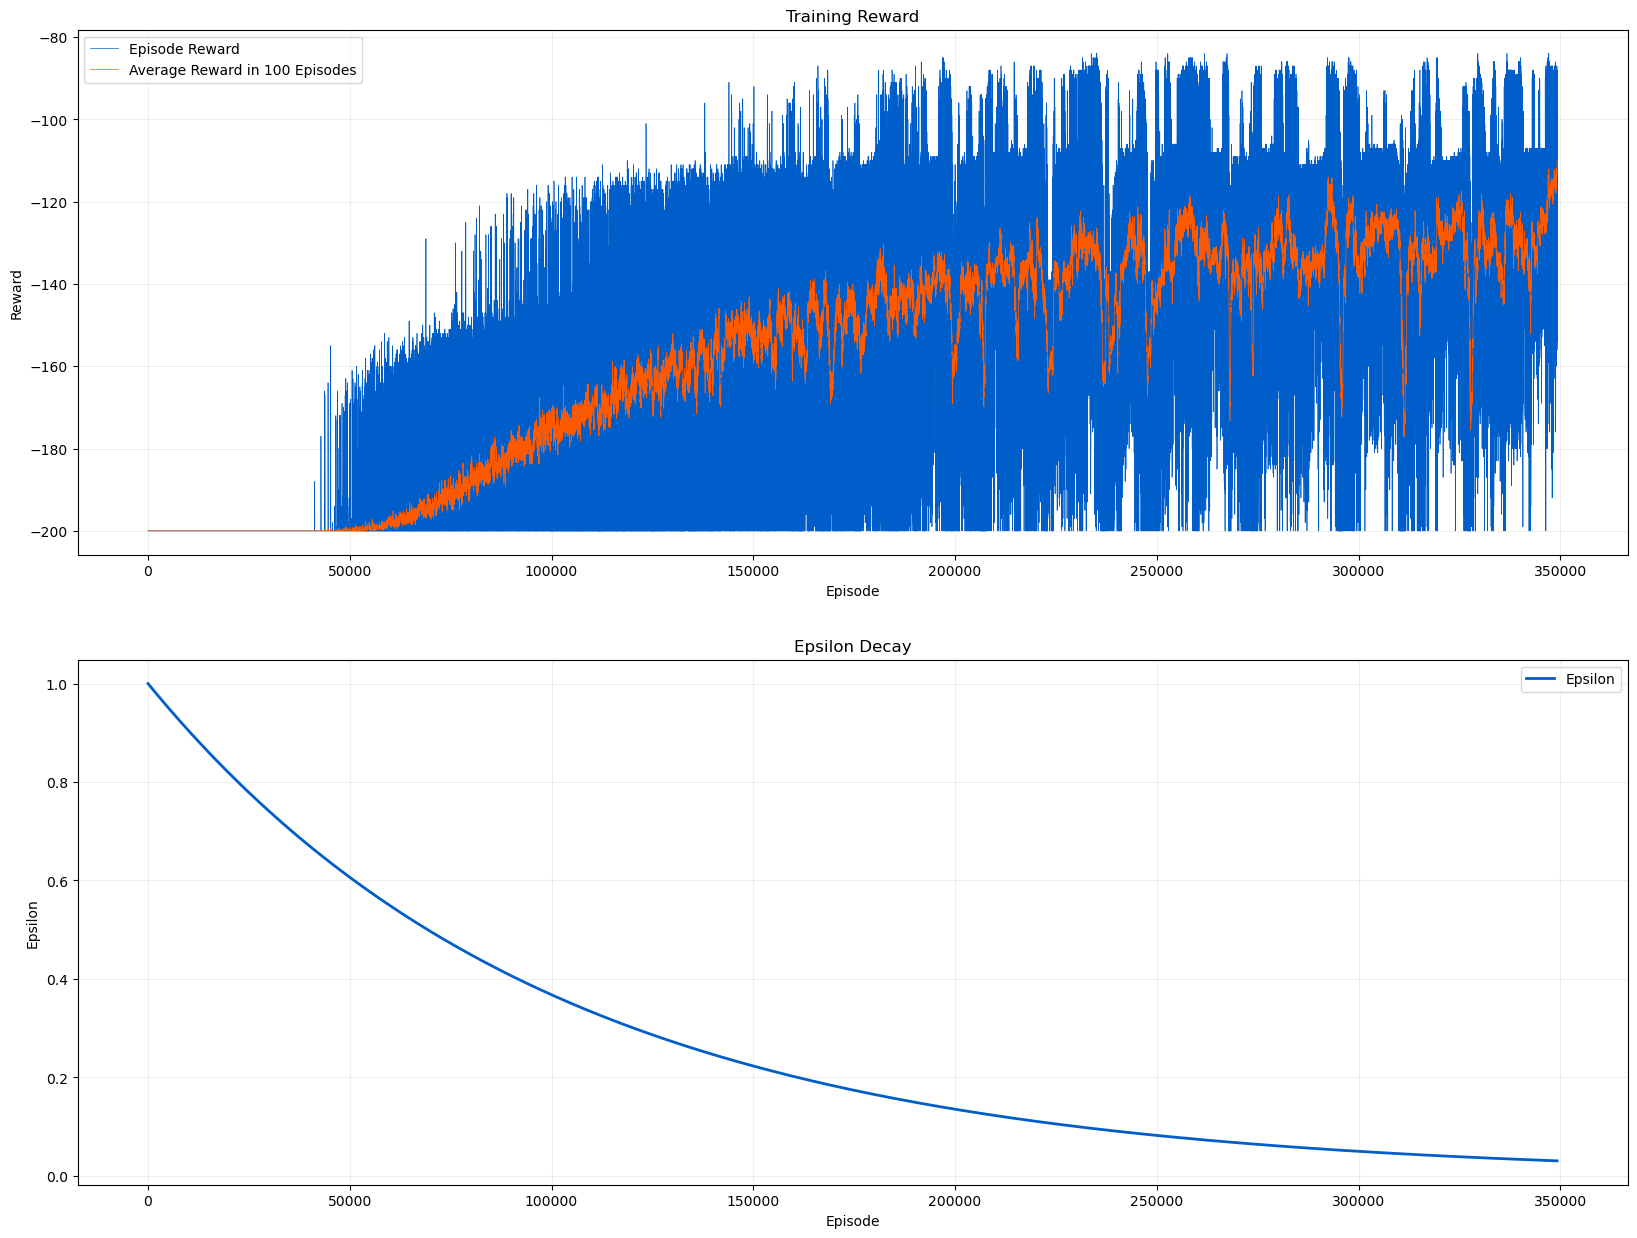

In [13]:
figure, axes = plt.subplots(2, 1, figsize=(20, 15))

axes[0].plot(scores, color="#005ECA", linewidth=0.5, label="Episode Reward")
axes[0].plot(avg_scores, color="#FF5900", linewidth=0.5, label="Average Reward in 100 Episodes")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Reward")
axes[0].set_title("Training Reward")
axes[0].legend()
axes[0].grid(True, alpha=0.2)

axes[1].plot(epsilons, color="#005ECA", linewidth=2, label="Epsilon")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Epsilon")
axes[1].set_title("Epsilon Decay")
axes[1].legend()
axes[1].grid(True, alpha=0.2)

plt.show()

### **<span style='color: #003ab9'>Convergence</span>**
- The Slow Start (Episodes 0 to 40000): In the beginning, the car does not learn anything useful. The average reward stays at a flat line of -200. This means the car runs out of time on every single try without reaching the flag. This is normal because the track gives no rewards until the car actually hits the flag, making it hard to find at first by just guessing.
- Finding the Flag (40000 to 200000): As the car explores less (when $\epsilon$ drops below 0.7), it finally finds the flag. We can see the orange line (the 100-episode average) start to climb up. This shows that the car is successfully passing the good news backward through its memory table to remember the moves that led to success.
- Settling Down (200000 onwards): The orange line stops climbing and flattens out, staying mostly between -140 and -110. Since it keeps reaching above -110 (the goal line set by the environment), it means the car has successfully learned a solid, reliable way to get up the hill.

### **<span style='color: #003ab9'>Stability</span>**
- Big Ups and Downs: Even after the orange line levels off at a good score, the raw scores (the blue lines) still jump all the way down to -200 quite often for these reasons:  
    - Random Guessing: Even late in the game (around episode 300000), the exploration rate ($\epsilon$) is still around 0.05 instead of dropping to absolute zero. This makes the car make a random wrong move every now and then, which ruins its speed and makes it fail the round.
    - Grid Numbers: Because the continuous values of Position and Velocity are chopped up into fixed boxes on a grid, tiny rounding errors happen. If the car chooses a bad action by even a tiny bit, it loses its speed in the valley and has to waste many steps trying to build up momentum again. 
   
### **<span style='color: #003ab9'>Accumulation</span>** 
- Over time, the blue lines split into two very clear groups:
    - The Winning Group (-110 to -85): This shows the rounds where the car used its speed perfectly and climbed the right hill on its first or second try.
    - The Failing Group (Right at -200): These are the rounds where a random bad move ruined the car's timing, leaving it stuck at the bottom of the hill until the clock ran out.
- More Wins Over Time: As you look closer at the right side of the plot, the blue lines get much thicker and more crowded near the top. This proves that the car runs successful episodes much more often as it gets closer to the end of training.

### **PART 3: AGENT EVALUATION**

In [10]:
eval_scores = visual_agent.evaluate(episodes=100)

print("Evaluation without exploration")
print("Mean evaluation score:", np.mean(eval_scores))
print("Best evaluation score:", np.max(eval_scores))
print("Worst evaluation score:", np.min(eval_scores))

Evaluation without exploration
Mean evaluation score: -110.43
Best evaluation score: -87.0
Worst evaluation score: -153.0


In [11]:
watch_agent(visual_agent, episodes=5)

/home/saman/Desktop/Artificial Intelligence/AI/lib/python3.12/site-packages/gym/utils/passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


Episode 1 reward: -107.0
Episode 2 reward: -109.0
Episode 3 reward: -89.0
Episode 4 reward: -110.0
Episode 5 reward: -109.0


Now we see that the agent has learned so much (Ghorboonesh Beram!) and is able to reach the goal at every try.

In [5]:
def plot_training_result(scores, avg_scores, epsilons, title):
    """
    Plot training performance of the agent.

    1. Plot episode rewards.
    2. Plot moving average reward over the last 100 episodes.
    3. Plot epsilon values over episodes.
    """
    figure, axes = plt.subplots(2, 1, figsize=(20, 15))
    axes[0].plot(scores, color="#0087C1", linewidth=0.5, label="Epsiode Reward")
    axes[0].plot(avg_scores, color="#FF1AFF", linewidth=0.5, label="Average Reward in 100 Episodes")
    axes[0].axhline(y=-110, color="red", linestyle="--", label="Threshold")
    axes[0].set_xlabel("Episode")
    axes[0].set_ylabel("Reward")
    axes[0].set_title(f"{title} Episode Rewards")
    axes[0].legend()
    axes[0].grid(True, alpha=0.2)

    axes[1].plot(epsilons, color="#0087C1", linewidth=2, label="Epsilon")
    axes[1].set_xlabel("Episode")
    axes[1].set_ylabel("Epsilon")
    axes[1].set_title(f"{title} Epsilon Decay")
    axes[1].legend()
    axes[1].grid(True, alpha=0.2)

    plt.show()

def run_epsilon_experiments(episodes=100000, buckets=(40, 40), seed=400):
    """
    Run experiments comparing different epsilon strategies.

    1. Train agents using different epsilon strategies.
    2. Store training results.
    3. Evaluate the trained agents.
    4. Plot training results for each strategy.
    5. Plot comparison charts between strategies.
    """
    strategies = ['constant', 'linear', 'logarithmic', 'exponential']
    results = {}

    print("--- Running Epsilon Strategy Experiments ---")

    for strategy in strategies:
        print(f"Training using {strategy} Strategy")
        env = gym.make('MountainCar-v0')
        agent = QLearningAgent(
            env,
            buckets=buckets,
            epsilon_strategy=strategy,
            episodes=episodes,
            seed=seed
        )
        
        scores, avg_scores, epsilons, shaped_scores = agent.train()
        eval_scores = agent.evaluate()
        env.close()

        results[strategy] = {
            "scores": scores,
            "avg_scores": avg_scores,
            "epsilons": epsilons,
            "eval_scores": eval_scores
        }

        print("===================================")
        print("Mean evaluation score:", np.mean(eval_scores))
        print("Best evaluation score:", np.max(eval_scores))
        print("Worst evaluation score:", np.min(eval_scores))
        print("===================================")

        plot_training_result(scores, avg_scores, epsilons, f"Strategy: {strategy}")

    figure, axes = plt.subplots(2, 1, figsize=(20, 15))
    colors = ["#D11FCB", "#000DCA", "#179A00", "#940000"]
    for i, strategy in enumerate(strategies):
        axes[0].plot(results[strategy]["avg_scores"], color=colors[i], linewidth=2, alpha=0.8, label=strategy)
        axes[1].plot(results[strategy]["epsilons"], color=colors[i], linewidth=2, alpha=0.8, label=strategy)

    axes[0].axhline(y=-110, color="#000000", linestyle="--", label="Threshold")
    axes[0].set_xlabel("Episodes")
    axes[0].set_ylabel("Reward")
    axes[0].set_title("Comparison of Epsilon Strategies in Average Reward")
    axes[0].legend()
    axes[0].grid(True, alpha=0.2)

    axes[1].set_xlabel("Episodes")
    axes[1].set_ylabel("Epsilon")
    axes[1].set_title("Comparison of Epsilon Strategies in Epsilon Value")
    axes[1].legend()
    axes[1].grid(True, alpha=0.2)

    plt.show()

    return results


def run_bucket_experiments(episodes=100000, seed=400):
    """
    Run experiments with different discretization bucket sizes.

    1. Train agents with different discretization grids.
    2. Compare their training performance.
    3. Plot the results.
    """

    grids = [(5, 5), (40, 40), (60, 60), (100, 100)]
    results = {}

    print("\n--- Running Discretization Bucket Experiments ---")

    for grid in grids:
        print(f"Training {grid} Grid")
        env = gym.make('MountainCar-v0')
        agent = QLearningAgent(
            env,
            buckets=grid,
            episodes=episodes,
            seed=seed
        )
        
        scores, avg_scores, epsilons, shaped_scores = agent.train()
        eval_scores = agent.evaluate()
        env.close()

        results[grid] = {
            "scores": scores,
            "avg_scores": avg_scores,
            "epsilons": epsilons,
            "eval_scores": eval_scores
        }

        print("===================================")
        print("Mean evaluation score:", np.mean(eval_scores))
        print("Best evaluation score:", np.max(eval_scores))
        print("Worst evaluation score:", np.min(eval_scores))
        print("===================================")

        plot_training_result(scores, avg_scores, epsilons, f"Buckets: {grid}")

    plt.figure(figsize=(20,15))
    colors = ["#D11FCB", "#000DCA", "#179A00", "#940000"]
    for i, grid in enumerate(results.keys()):
        plt.plot(results[grid]["avg_scores"], color=colors[i], linewidth=2, alpha=0.8, label=str(grid))

    plt.axhline(y=-110, color="#000000", linestyle="--", label="Threshold")
    plt.xlabel("Episodes")
    plt.ylabel("Reward")
    plt.title("Comparison of Epsilon Strategies in Average Reward")
    plt.legend()
    plt.grid(True, alpha=0.2)

    plt.show()

    return results

--- Running Epsilon Strategy Experiments ---
Training using constant Strategy
threshold: -110.0
Episode 5000/100000 | Average Reward: -199.60 | Epsilon: 0.1000
Episode 10000/100000 | Average Reward: -188.60 | Epsilon: 0.1000
Episode 15000/100000 | Average Reward: -179.10 | Epsilon: 0.1000
Episode 20000/100000 | Average Reward: -157.09 | Epsilon: 0.1000
Episode 25000/100000 | Average Reward: -161.22 | Epsilon: 0.1000
Episode 30000/100000 | Average Reward: -143.07 | Epsilon: 0.1000
Episode 35000/100000 | Average Reward: -146.12 | Epsilon: 0.1000
Episode 40000/100000 | Average Reward: -157.37 | Epsilon: 0.1000
Episode 45000/100000 | Average Reward: -139.12 | Epsilon: 0.1000
Episode 50000/100000 | Average Reward: -144.82 | Epsilon: 0.1000
Episode 55000/100000 | Average Reward: -145.58 | Epsilon: 0.1000
Episode 60000/100000 | Average Reward: -138.21 | Epsilon: 0.1000
Episode 65000/100000 | Average Reward: -133.84 | Epsilon: 0.1000
Episode 70000/100000 | Average Reward: -149.35 | Epsilon: 0.

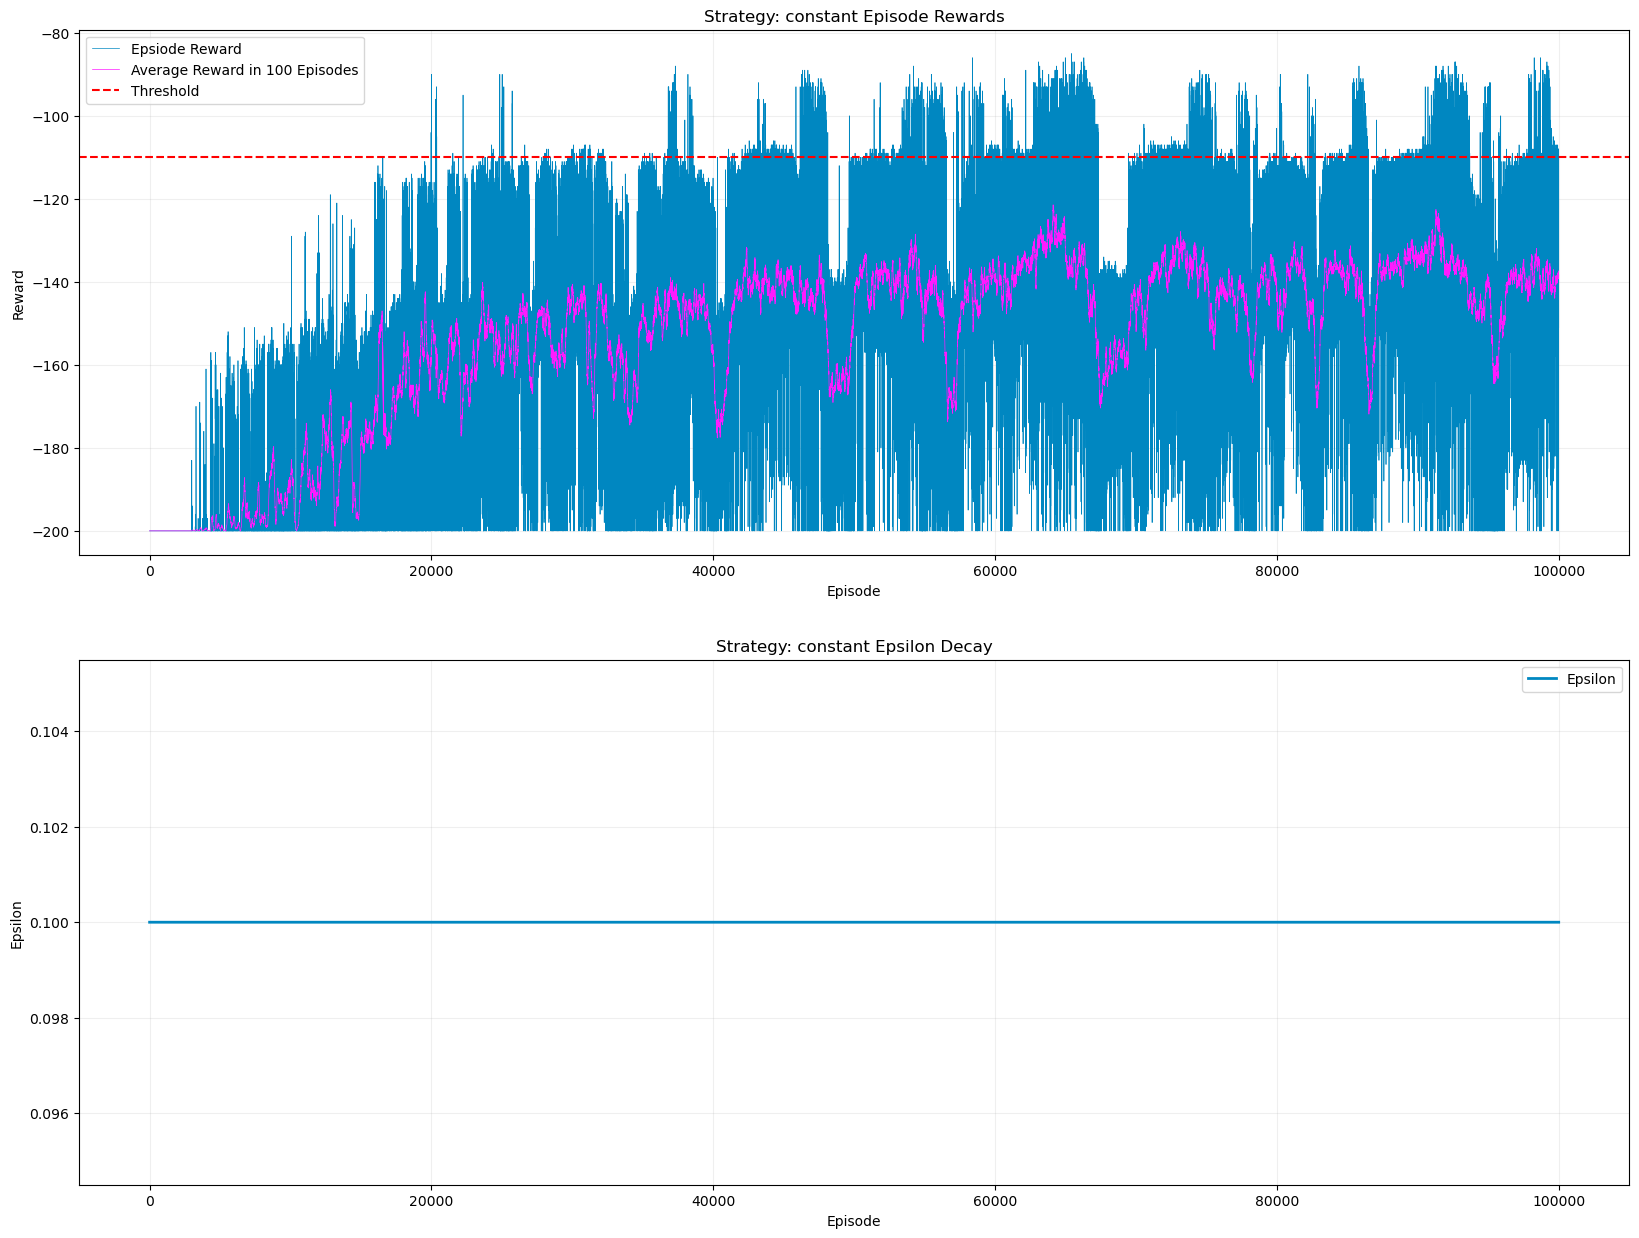

Training using linear Strategy
threshold: -110.0
Episode 5000/100000 | Average Reward: -200.00 | Epsilon: 0.9500
Episode 10000/100000 | Average Reward: -200.00 | Epsilon: 0.9000
Episode 15000/100000 | Average Reward: -200.00 | Epsilon: 0.8500
Episode 20000/100000 | Average Reward: -200.00 | Epsilon: 0.8000
Episode 25000/100000 | Average Reward: -200.00 | Epsilon: 0.7500
Episode 30000/100000 | Average Reward: -200.00 | Epsilon: 0.7000
Episode 35000/100000 | Average Reward: -200.00 | Epsilon: 0.6500
Episode 40000/100000 | Average Reward: -199.61 | Epsilon: 0.6000
Episode 45000/100000 | Average Reward: -198.65 | Epsilon: 0.5500
Episode 50000/100000 | Average Reward: -195.01 | Epsilon: 0.5000
Episode 55000/100000 | Average Reward: -189.97 | Epsilon: 0.4500
Episode 60000/100000 | Average Reward: -184.33 | Epsilon: 0.4000
Episode 65000/100000 | Average Reward: -173.74 | Epsilon: 0.3500
Episode 70000/100000 | Average Reward: -172.58 | Epsilon: 0.3000
Episode 75000/100000 | Average Reward: -16

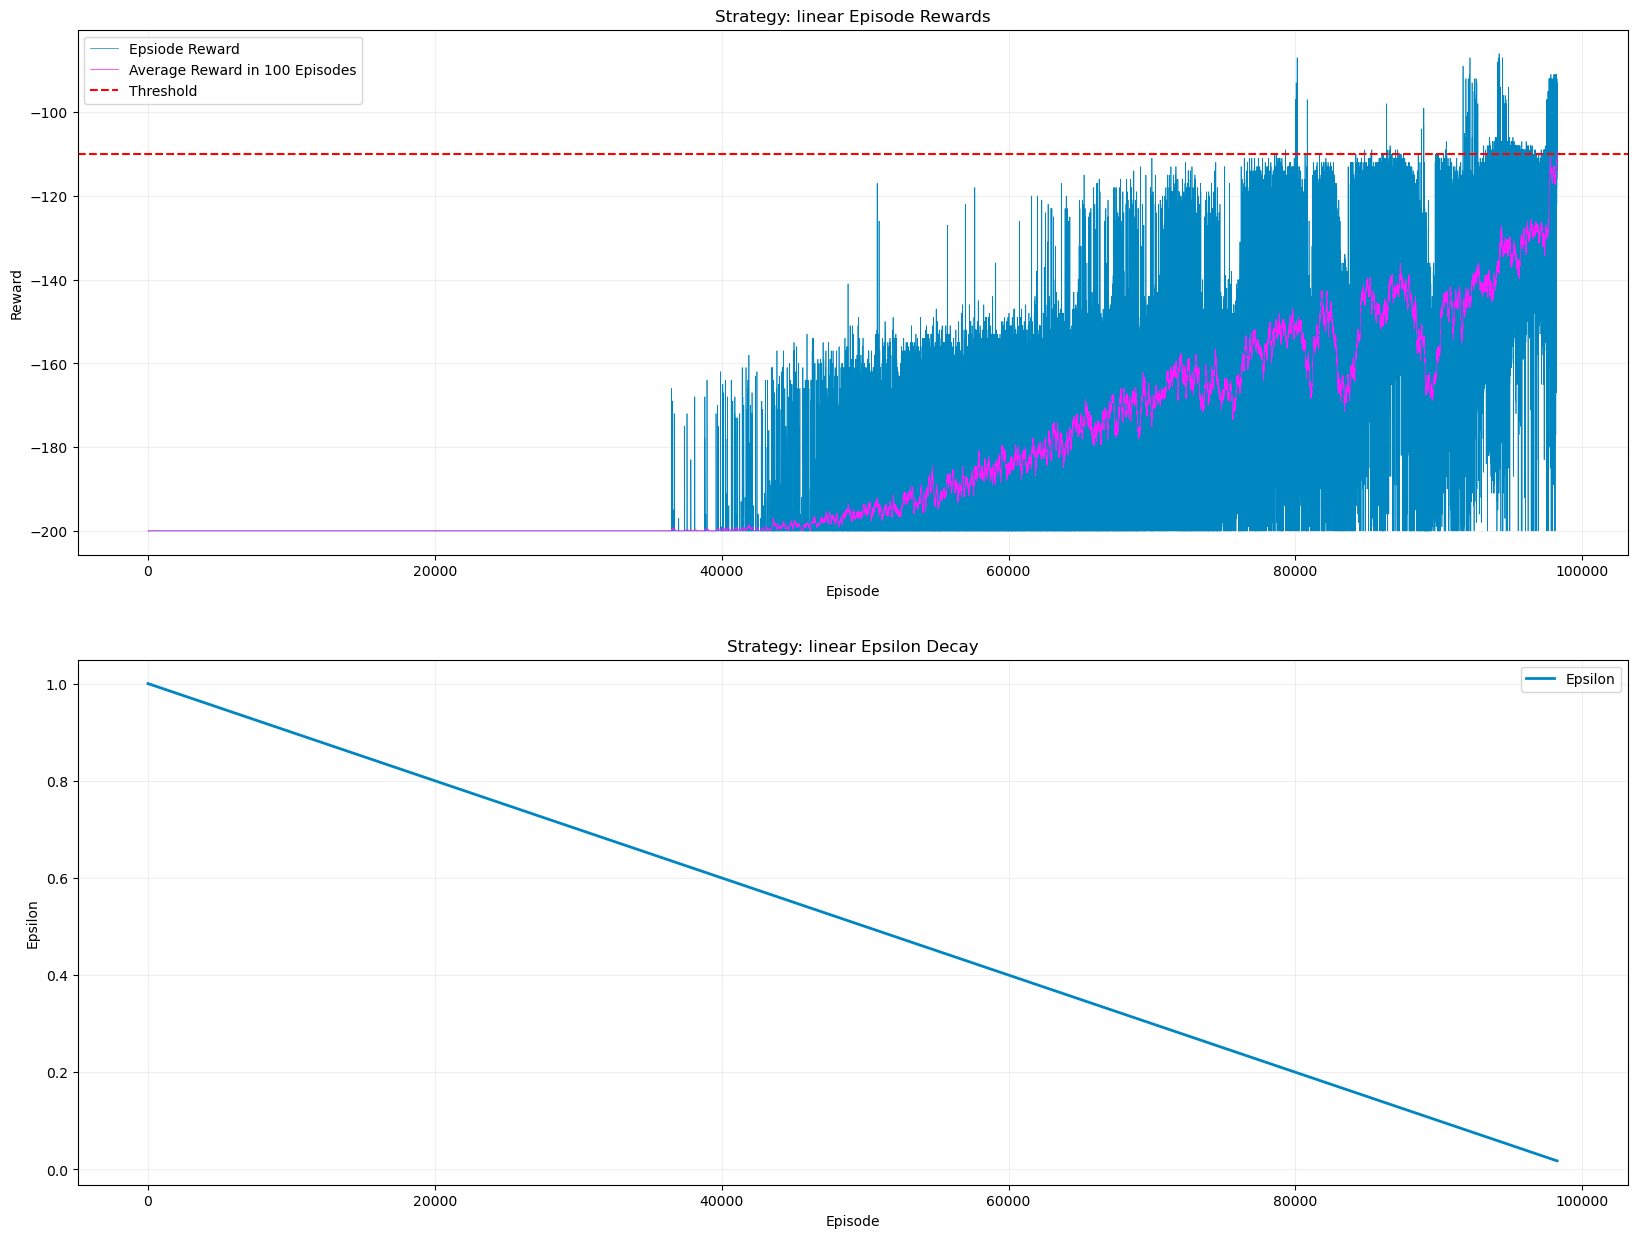

Training using logarithmic Strategy
threshold: -110.0
Episode 5000/100000 | Average Reward: -199.92 | Epsilon: 0.2703
Episode 10000/100000 | Average Reward: -193.80 | Epsilon: 0.2500
Episode 15000/100000 | Average Reward: -173.53 | Epsilon: 0.2395
Episode 20000/100000 | Average Reward: -167.53 | Epsilon: 0.2325
Episode 25000/100000 | Average Reward: -168.22 | Epsilon: 0.2274
Episode 30000/100000 | Average Reward: -162.07 | Epsilon: 0.2234
Episode 35000/100000 | Average Reward: -156.64 | Epsilon: 0.2201
Episode 40000/100000 | Average Reward: -155.39 | Epsilon: 0.2173
Episode 45000/100000 | Average Reward: -155.66 | Epsilon: 0.2149
Episode 50000/100000 | Average Reward: -155.03 | Epsilon: 0.2128
Episode 55000/100000 | Average Reward: -155.29 | Epsilon: 0.2110
Episode 60000/100000 | Average Reward: -162.72 | Epsilon: 0.2093
Episode 65000/100000 | Average Reward: -150.00 | Epsilon: 0.2078
Episode 70000/100000 | Average Reward: -149.95 | Epsilon: 0.2064
Episode 75000/100000 | Average Reward

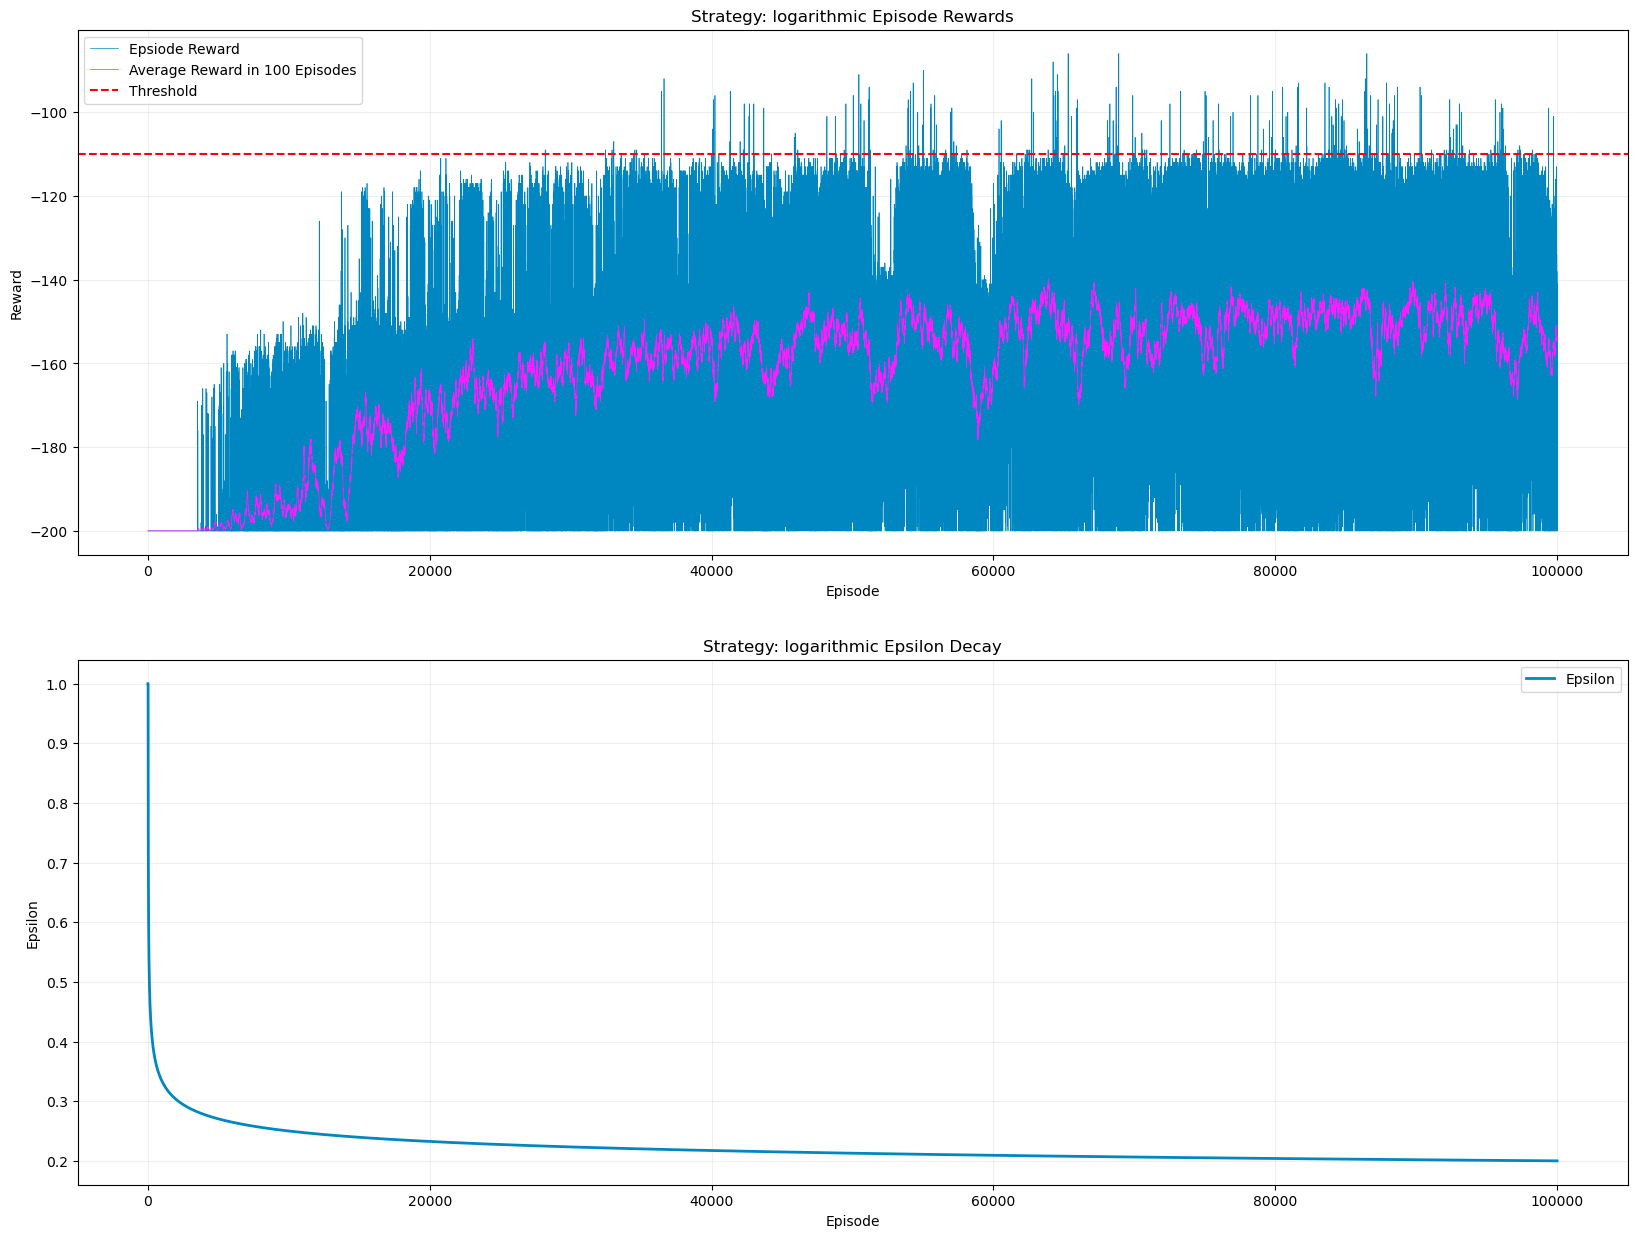

Training using exponential Strategy
threshold: -110.0
Episode 5000/100000 | Average Reward: -200.00 | Epsilon: 0.7788
Episode 10000/100000 | Average Reward: -200.00 | Epsilon: 0.6066
Episode 15000/100000 | Average Reward: -197.88 | Epsilon: 0.4724
Episode 20000/100000 | Average Reward: -187.53 | Epsilon: 0.3679
Episode 25000/100000 | Average Reward: -178.28 | Epsilon: 0.2865
Episode 30000/100000 | Average Reward: -168.05 | Epsilon: 0.2231
Episode 35000/100000 | Average Reward: -165.46 | Epsilon: 0.1738
Episode 40000/100000 | Average Reward: -152.91 | Epsilon: 0.1353
Episode 45000/100000 | Average Reward: -138.65 | Epsilon: 0.1054
Episode 50000/100000 | Average Reward: -158.93 | Epsilon: 0.0821
Episode 55000/100000 | Average Reward: -142.32 | Epsilon: 0.0639
Episode 60000/100000 | Average Reward: -145.23 | Epsilon: 0.0498
Episode 65000/100000 | Average Reward: -119.66 | Epsilon: 0.0388
Episode 70000/100000 | Average Reward: -132.27 | Epsilon: 0.0302
Episode 75000/100000 | Average Reward

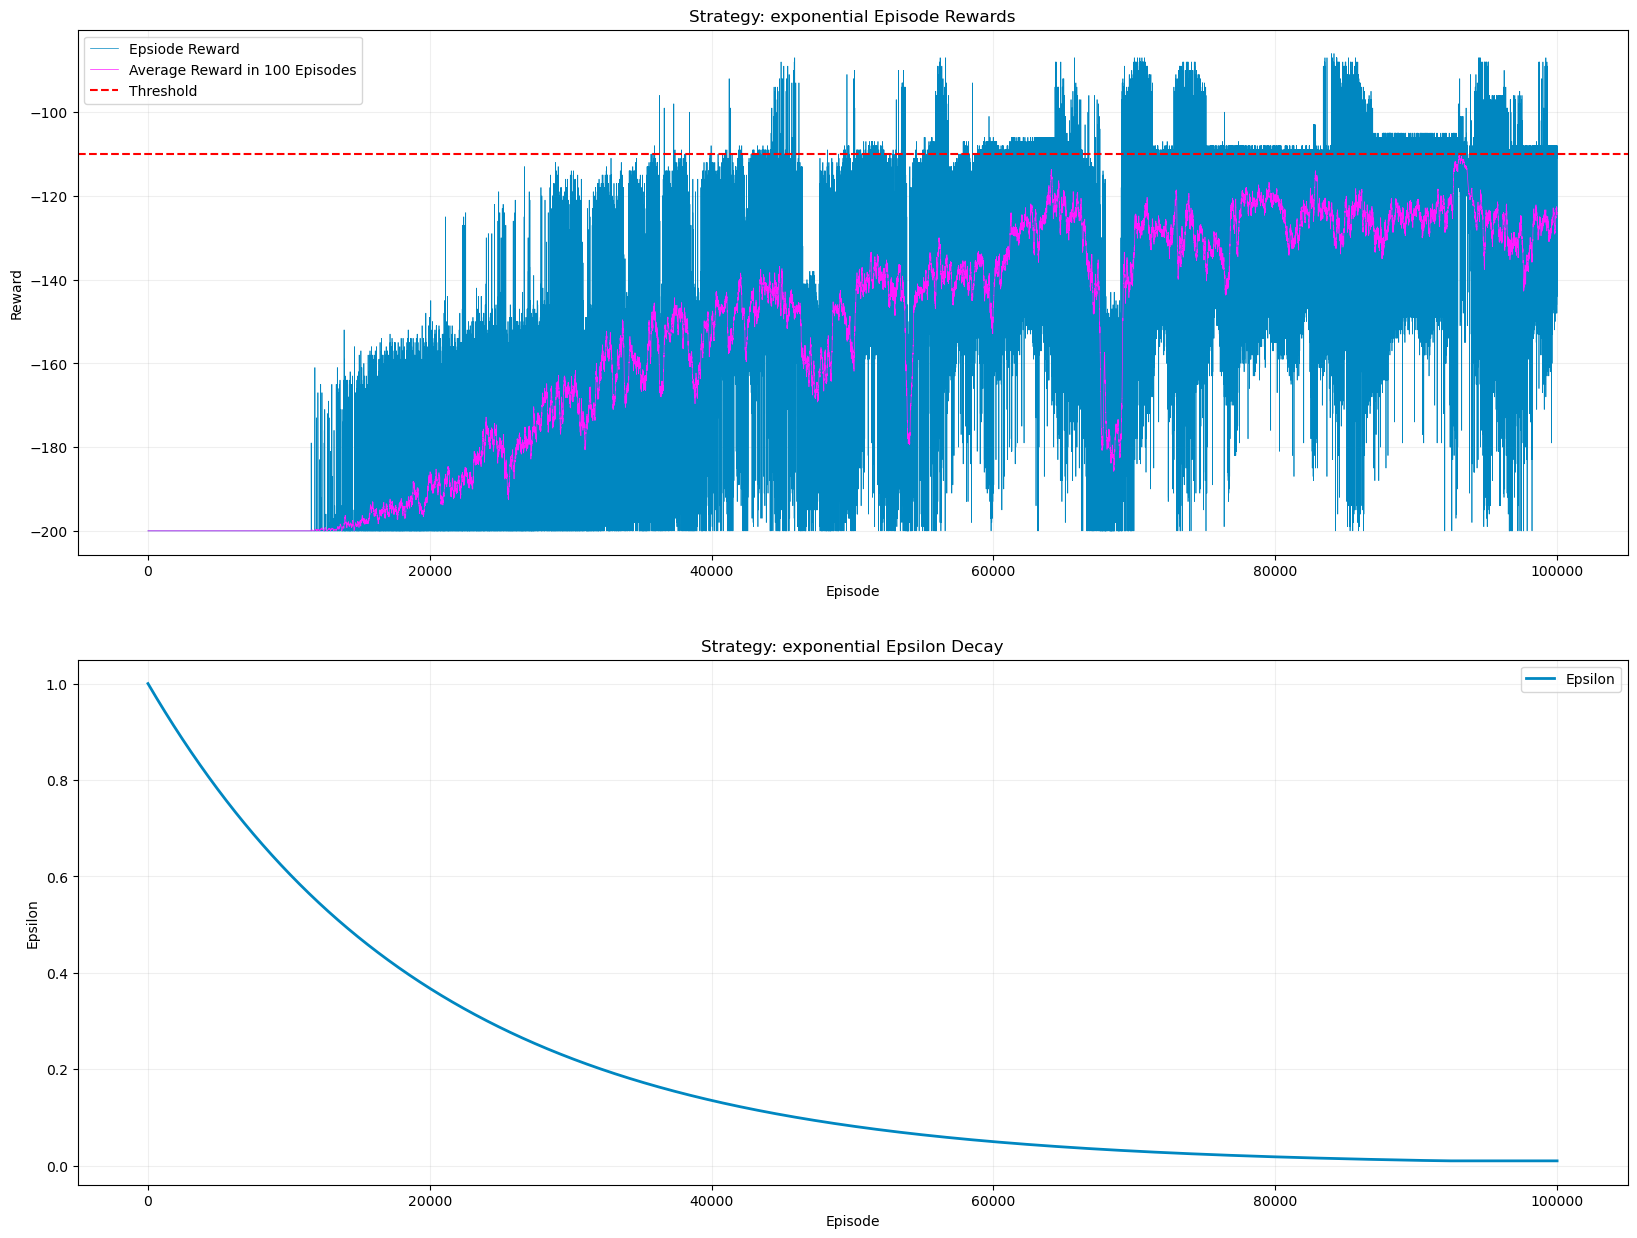

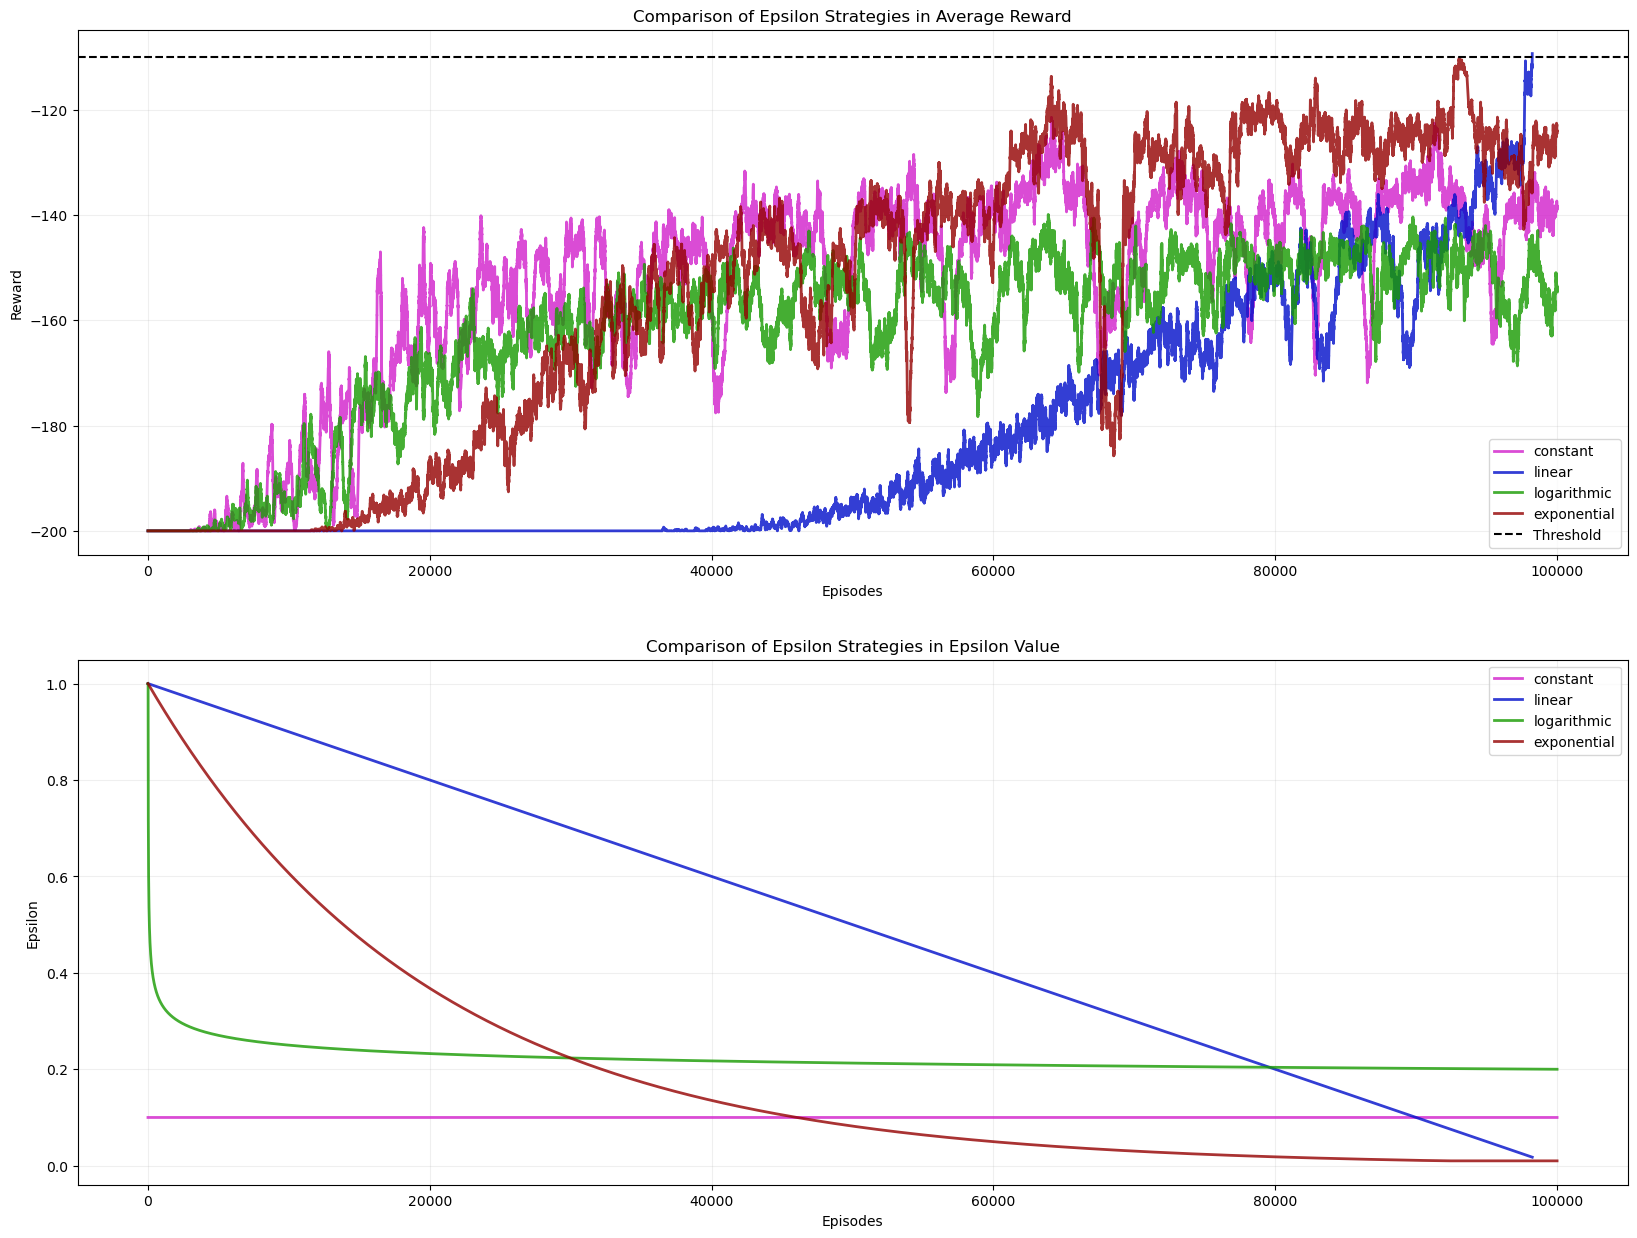

In [31]:
epsilon_results = run_epsilon_experiments(
    episodes=100000,
    buckets=(40, 40),
    seed=400
)

### <span style='color: #00b91f'>Constant Strategy</span>
- How it learns: Because the exploration rate is low right from the start, the agent stumbles upon the flag very early (around episode 10,000).
- The Problem: It hits a clear learning wall. The score gets stuck averaging around -138 and never really improves past that.
- Why it struggles: With $\epsilon$ locked at 0.10, the car forces a completely random action 10\% of the time. On Mountain Car, taking random bad actions constantly destroys the car's momentum. It can never perfect its policy because it shakes too much.

### <span style='color: #00b91f'>Linear Strategy</span>
- How it learns: This is the only strategy that successfully solved the environment.
- The Journey: It starts very slow. For the first 40000 episodes, the score stays completely stuck at -200 because $\epsilon$ is too high (above 0.60), meaning the car is just moving randomly and can't build focused speed. However, once $\epsilon$ drops below 0.30, learning explodes upward.
- Why it wins: It gives the agent plenty of time to find random paths early on, and cleanly shrinks exploration down to 0.05 at the end. This allows the car to firmly lock in its best moves without random noise messing it up.

### <span style='color: #00b91f'>Logarithmic Strategy</span>
- How it learns: This strategy drops its exploration rate very quickly at the beginning and then flattens, keeping $\epsilon$ around 0.20 for almost the entire run.
- The Result: Like the constant strategy, it finds the goal early because it drops its initial high randomness quickly. But it gets permanently trapped at a poor average score of around -150.
- Why it struggles: An exploration rate of 0.20 is way too high for late-stage training. The car spends 20\% of its time making random mistakes, which is too chaotic to allow it to learn the exact, precise timing needed to conquer the mountain.

### <span style='color: #00b91f'>Exponential Strategy</span>
- How it learns: This strategy decreases $\epsilon$ at a steady percentage rate, dropping exploration from 1.0 down to its minimum floor of 0.01 around episode.
- The Result: It shows a very beautiful, clean, and steady learning curve. Once the exploration rate hits the minimum floor (0.01), the average reward settles nicely at around -120.
- Why it missed the target: While it is highly stable, it didn't quite solve the environment threshold (-110). Because it cut off exploration too quickly early on, it settled into a decent, safe path rather than finding the absolute fastest way up the hill.


--- Running Discretization Bucket Experiments ---
Training (5, 5) Grid
threshold: -110.0


/home/saman/Desktop/Artificial Intelligence/AI/lib/python3.12/site-packages/gym/utils/passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


Episode 5000/100000 | Average Reward: -200.00 | Epsilon: 0.7788
Episode 10000/100000 | Average Reward: -200.00 | Epsilon: 0.6066
Episode 15000/100000 | Average Reward: -199.97 | Epsilon: 0.4724
Episode 20000/100000 | Average Reward: -200.00 | Epsilon: 0.3679
Episode 25000/100000 | Average Reward: -198.32 | Epsilon: 0.2865
Episode 30000/100000 | Average Reward: -198.42 | Epsilon: 0.2231
Episode 35000/100000 | Average Reward: -199.03 | Epsilon: 0.1738
Episode 40000/100000 | Average Reward: -197.43 | Epsilon: 0.1353
Episode 45000/100000 | Average Reward: -196.69 | Epsilon: 0.1054
Episode 50000/100000 | Average Reward: -193.31 | Epsilon: 0.0821
Episode 55000/100000 | Average Reward: -197.35 | Epsilon: 0.0639
Episode 60000/100000 | Average Reward: -188.60 | Epsilon: 0.0498
Episode 65000/100000 | Average Reward: -195.27 | Epsilon: 0.0388
Episode 70000/100000 | Average Reward: -193.14 | Epsilon: 0.0302
Episode 75000/100000 | Average Reward: -187.05 | Epsilon: 0.0235
Episode 80000/100000 | Ave

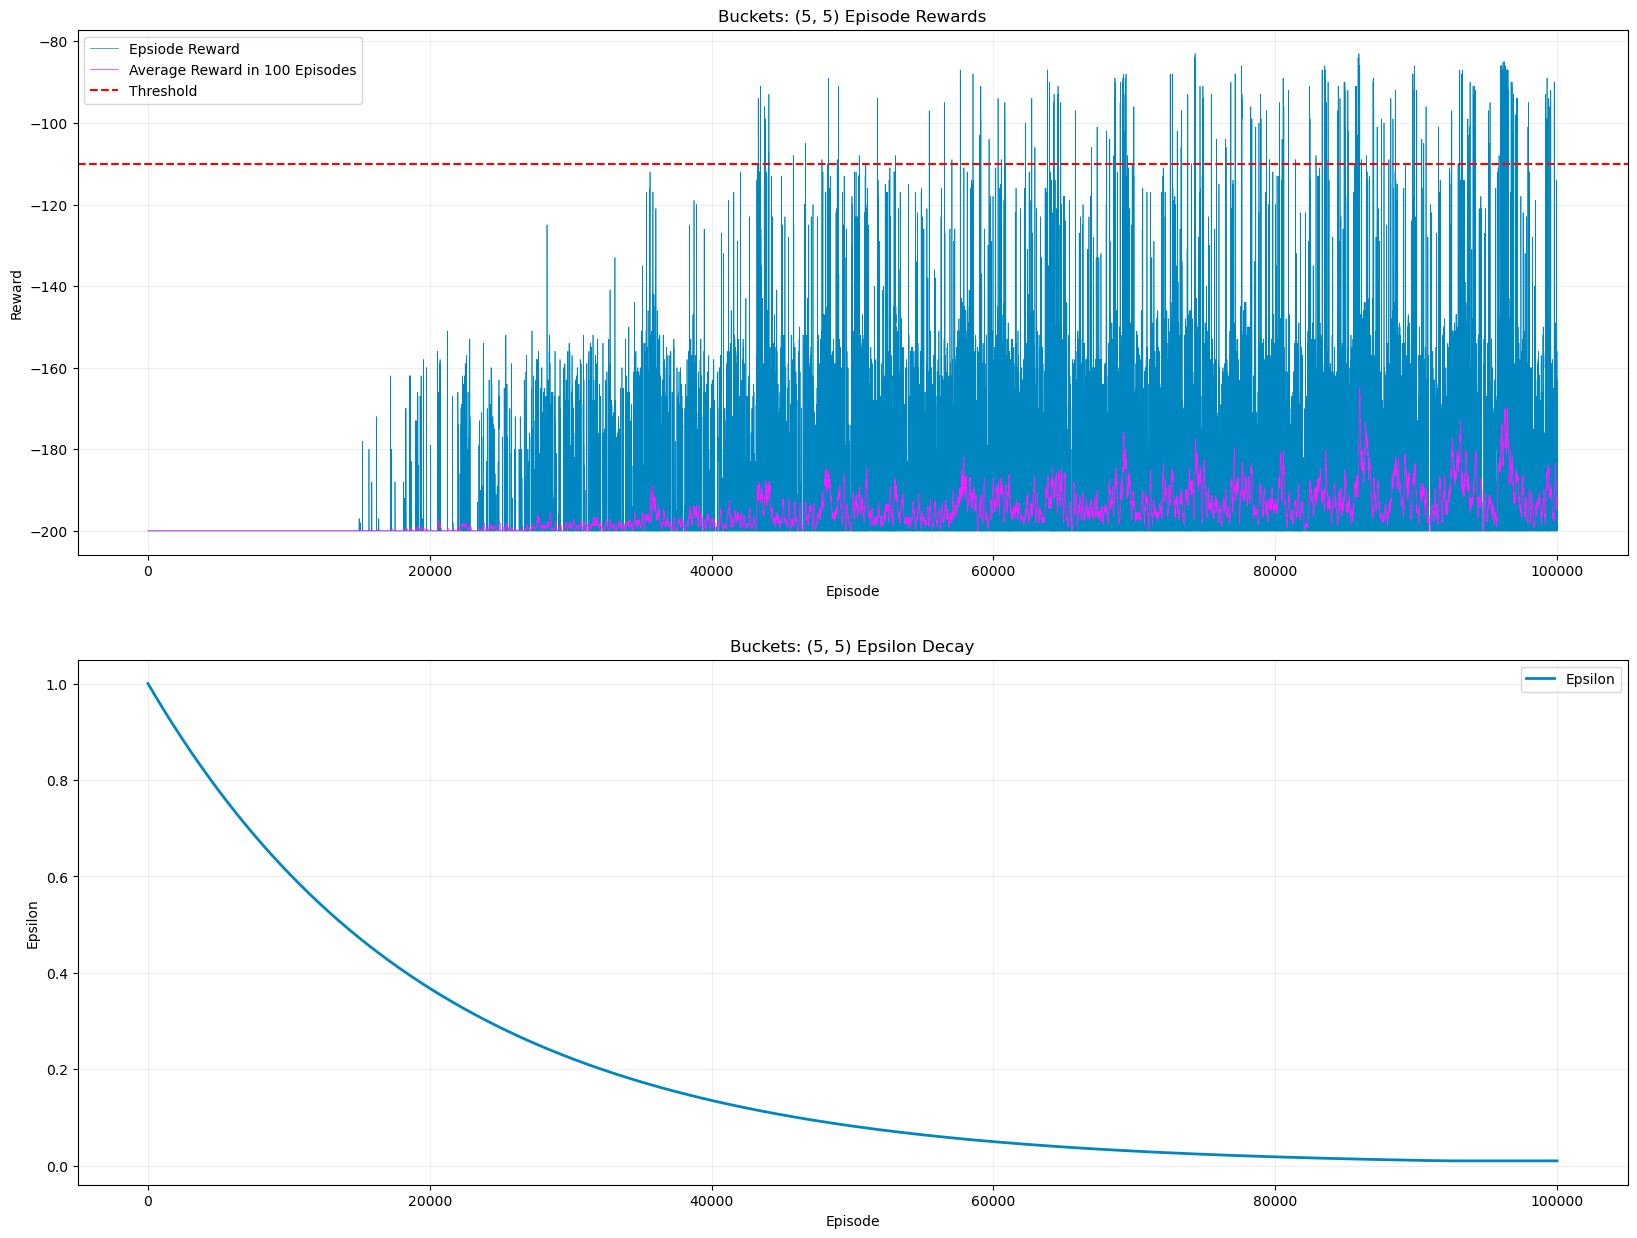

Training (40, 40) Grid
threshold: -110.0
Episode 5000/100000 | Average Reward: -200.00 | Epsilon: 0.7788
Episode 10000/100000 | Average Reward: -200.00 | Epsilon: 0.6066
Episode 15000/100000 | Average Reward: -197.88 | Epsilon: 0.4724
Episode 20000/100000 | Average Reward: -187.53 | Epsilon: 0.3679
Episode 25000/100000 | Average Reward: -178.28 | Epsilon: 0.2865
Episode 30000/100000 | Average Reward: -168.05 | Epsilon: 0.2231
Episode 35000/100000 | Average Reward: -165.46 | Epsilon: 0.1738
Episode 40000/100000 | Average Reward: -152.91 | Epsilon: 0.1353
Episode 45000/100000 | Average Reward: -138.65 | Epsilon: 0.1054
Episode 50000/100000 | Average Reward: -158.93 | Epsilon: 0.0821
Episode 55000/100000 | Average Reward: -142.32 | Epsilon: 0.0639
Episode 60000/100000 | Average Reward: -145.23 | Epsilon: 0.0498
Episode 65000/100000 | Average Reward: -119.66 | Epsilon: 0.0388
Episode 70000/100000 | Average Reward: -132.27 | Epsilon: 0.0302
Episode 75000/100000 | Average Reward: -132.30 | E

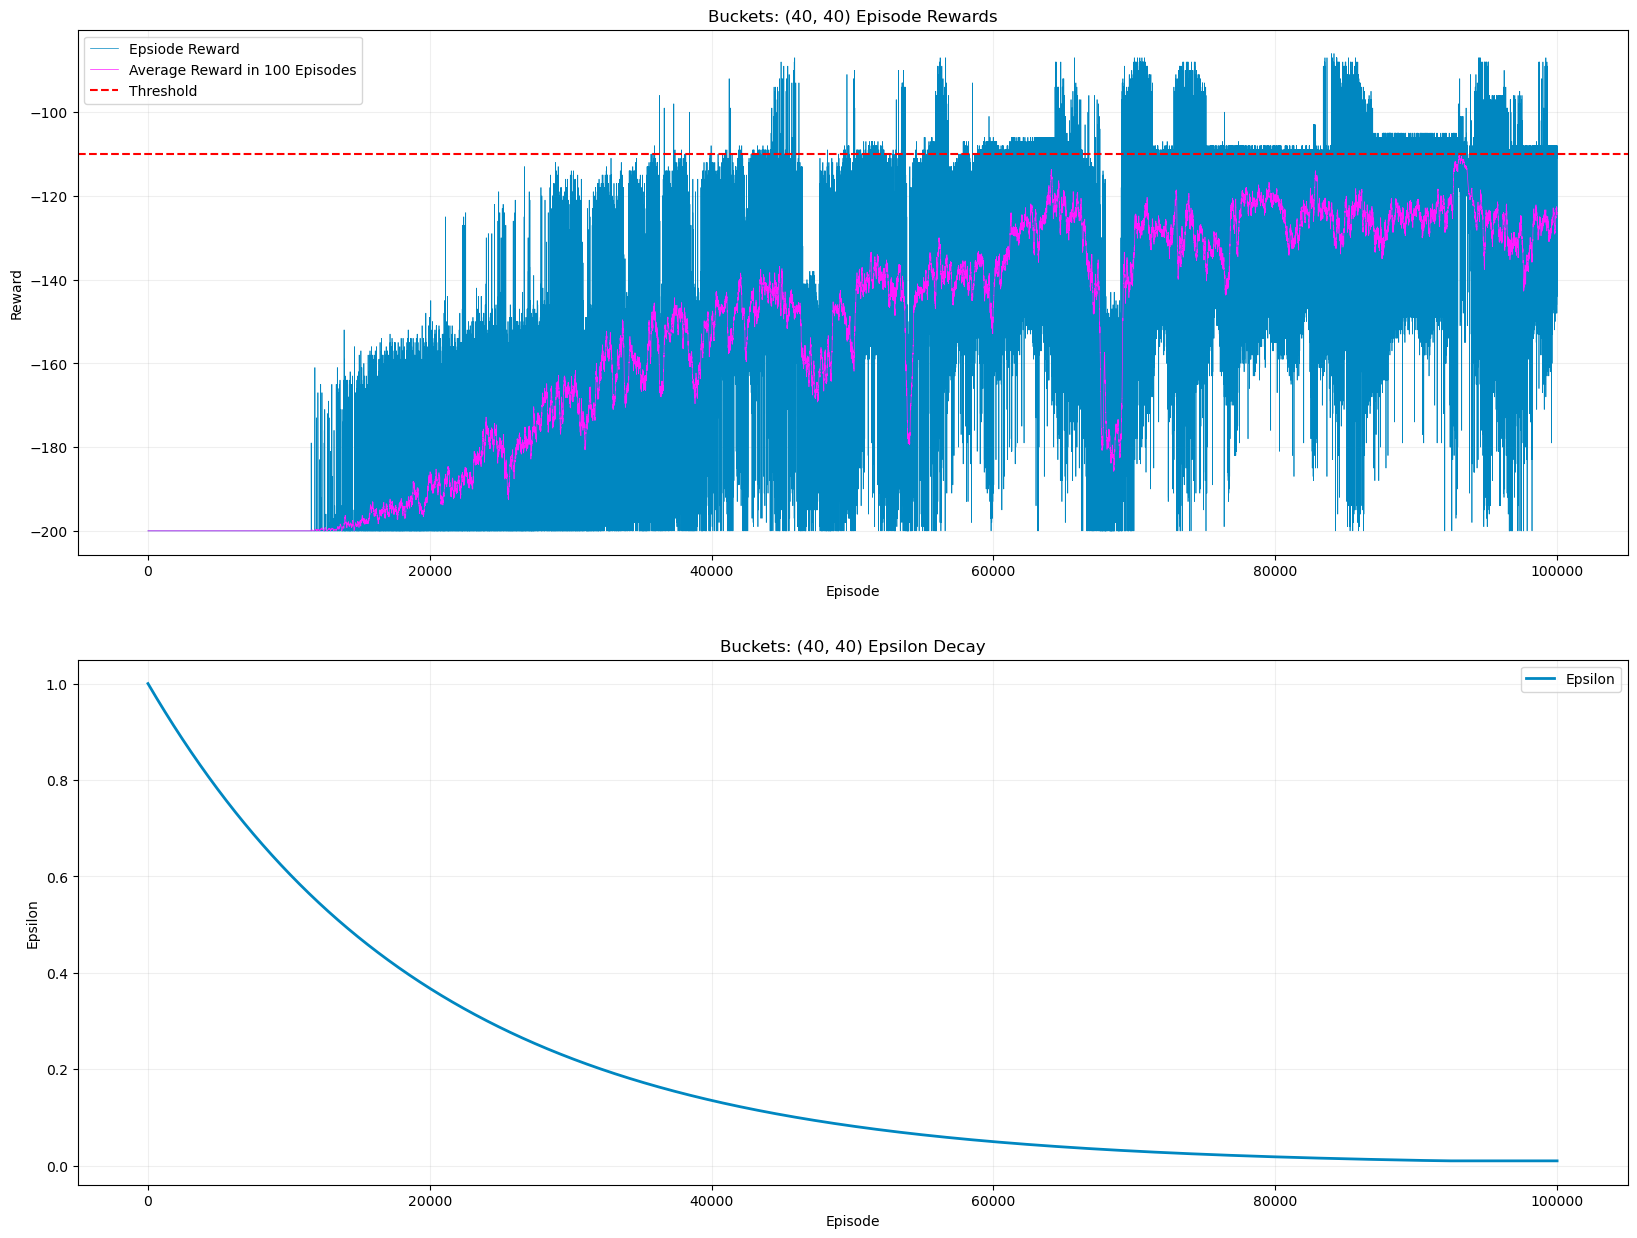

Training (60, 60) Grid
threshold: -110.0
Episode 5000/100000 | Average Reward: -200.00 | Epsilon: 0.7788
Episode 10000/100000 | Average Reward: -200.00 | Epsilon: 0.6066
Episode 15000/100000 | Average Reward: -199.01 | Epsilon: 0.4724
Episode 20000/100000 | Average Reward: -199.27 | Epsilon: 0.3679
Episode 25000/100000 | Average Reward: -194.47 | Epsilon: 0.2865
Episode 30000/100000 | Average Reward: -192.15 | Epsilon: 0.2231
Episode 35000/100000 | Average Reward: -180.07 | Epsilon: 0.1738
Episode 40000/100000 | Average Reward: -172.43 | Epsilon: 0.1353
Episode 45000/100000 | Average Reward: -160.29 | Epsilon: 0.1054
Episode 50000/100000 | Average Reward: -152.73 | Epsilon: 0.0821
Episode 55000/100000 | Average Reward: -144.09 | Epsilon: 0.0639
Episode 60000/100000 | Average Reward: -145.01 | Epsilon: 0.0498
Episode 65000/100000 | Average Reward: -140.12 | Epsilon: 0.0388
Episode 70000/100000 | Average Reward: -141.04 | Epsilon: 0.0302
Episode 75000/100000 | Average Reward: -146.72 | E

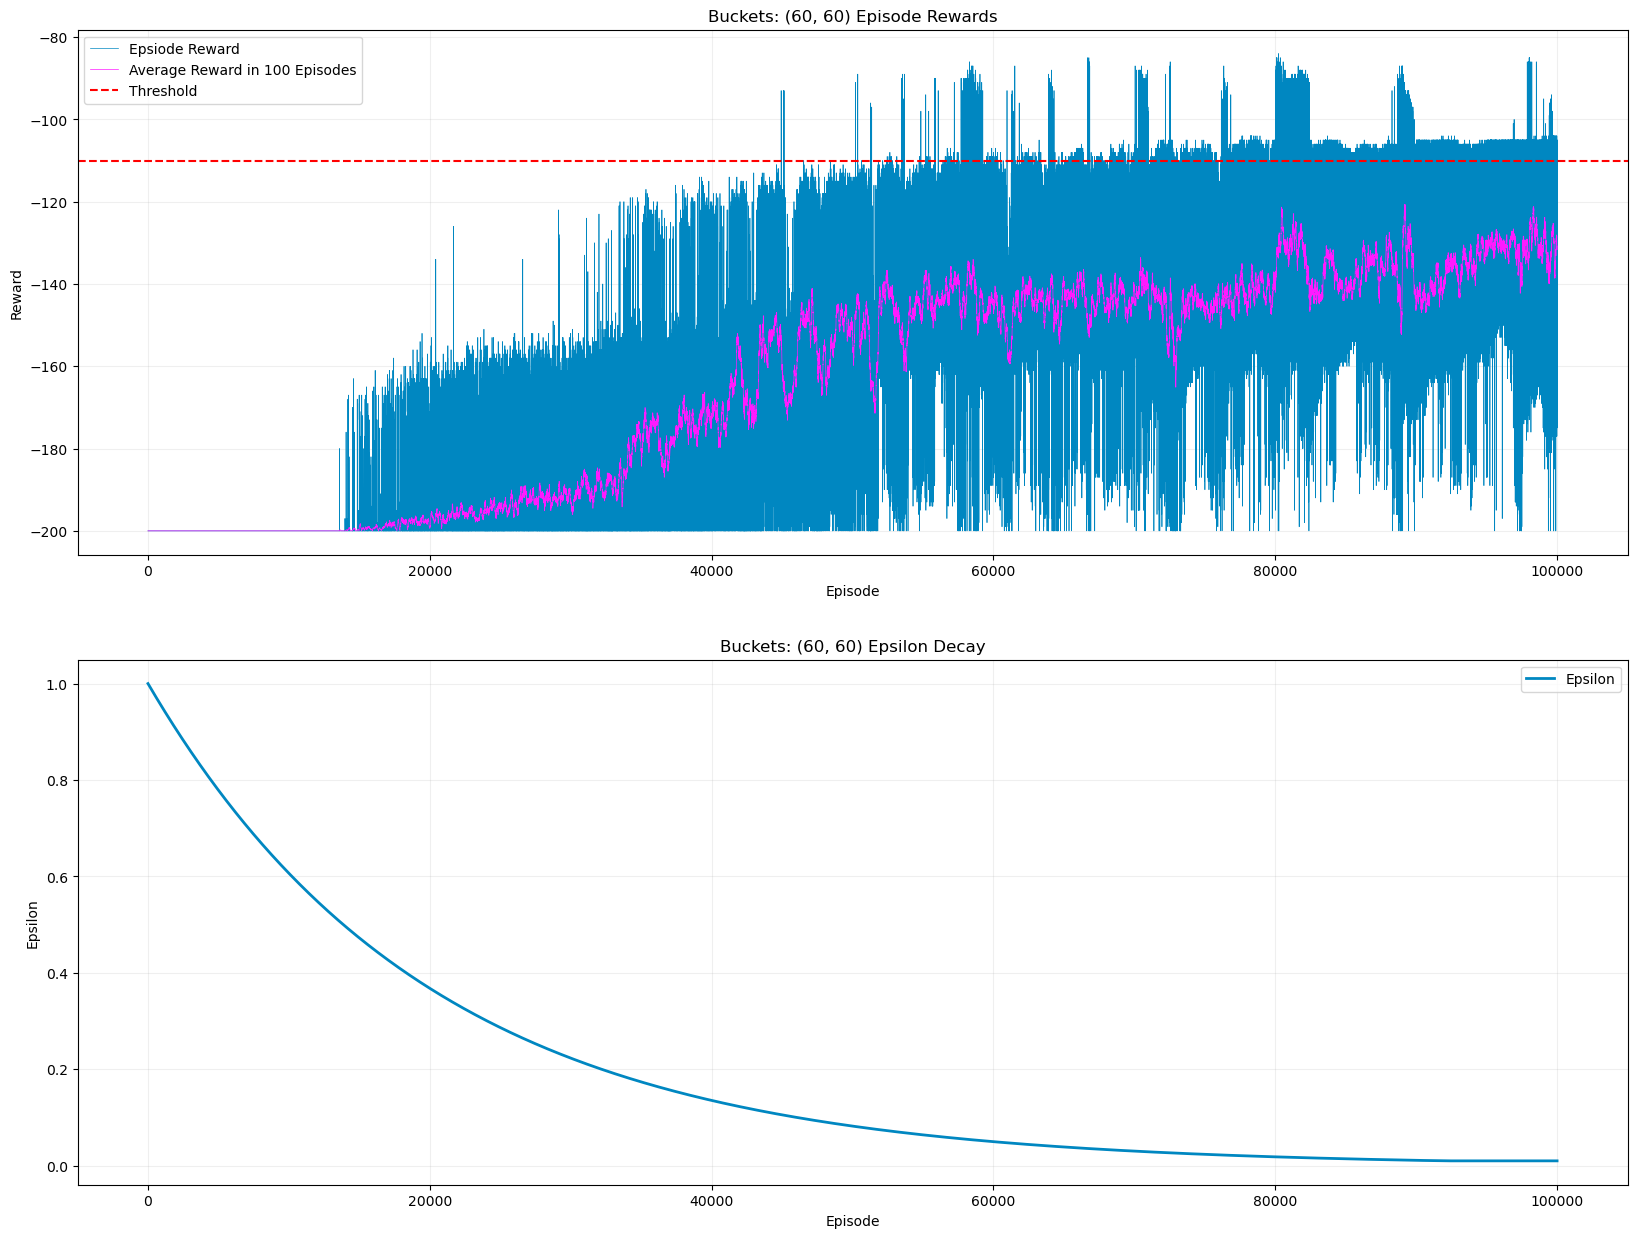

Training (100, 100) Grid
threshold: -110.0
Episode 5000/100000 | Average Reward: -200.00 | Epsilon: 0.7788
Episode 10000/100000 | Average Reward: -200.00 | Epsilon: 0.6066
Episode 15000/100000 | Average Reward: -200.00 | Epsilon: 0.4724
Episode 20000/100000 | Average Reward: -200.00 | Epsilon: 0.3679
Episode 25000/100000 | Average Reward: -199.99 | Epsilon: 0.2865
Episode 30000/100000 | Average Reward: -199.10 | Epsilon: 0.2231
Episode 35000/100000 | Average Reward: -198.84 | Epsilon: 0.1738
Episode 40000/100000 | Average Reward: -195.90 | Epsilon: 0.1353
Episode 45000/100000 | Average Reward: -196.24 | Epsilon: 0.1054
Episode 50000/100000 | Average Reward: -195.99 | Epsilon: 0.0821
Episode 55000/100000 | Average Reward: -193.79 | Epsilon: 0.0639
Episode 60000/100000 | Average Reward: -189.68 | Epsilon: 0.0498
Episode 65000/100000 | Average Reward: -191.72 | Epsilon: 0.0388
Episode 70000/100000 | Average Reward: -189.75 | Epsilon: 0.0302
Episode 75000/100000 | Average Reward: -185.57 |

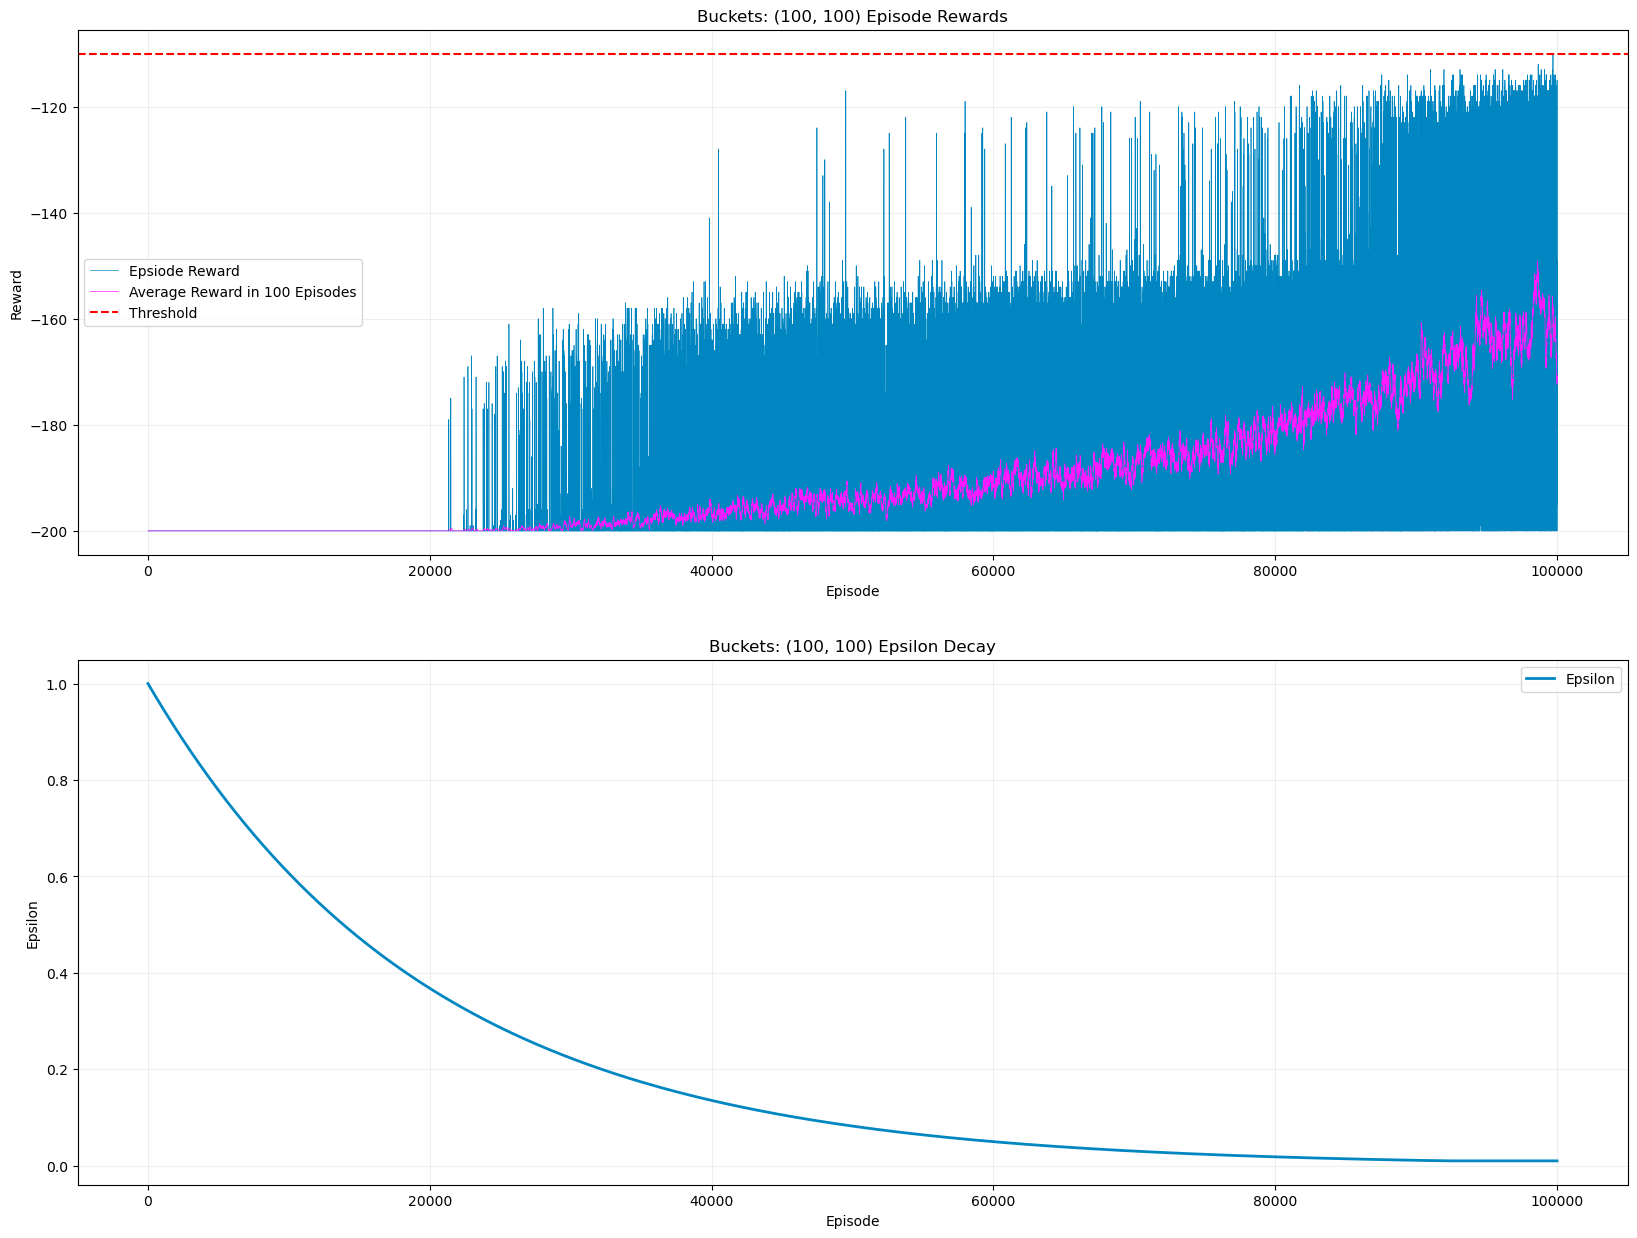

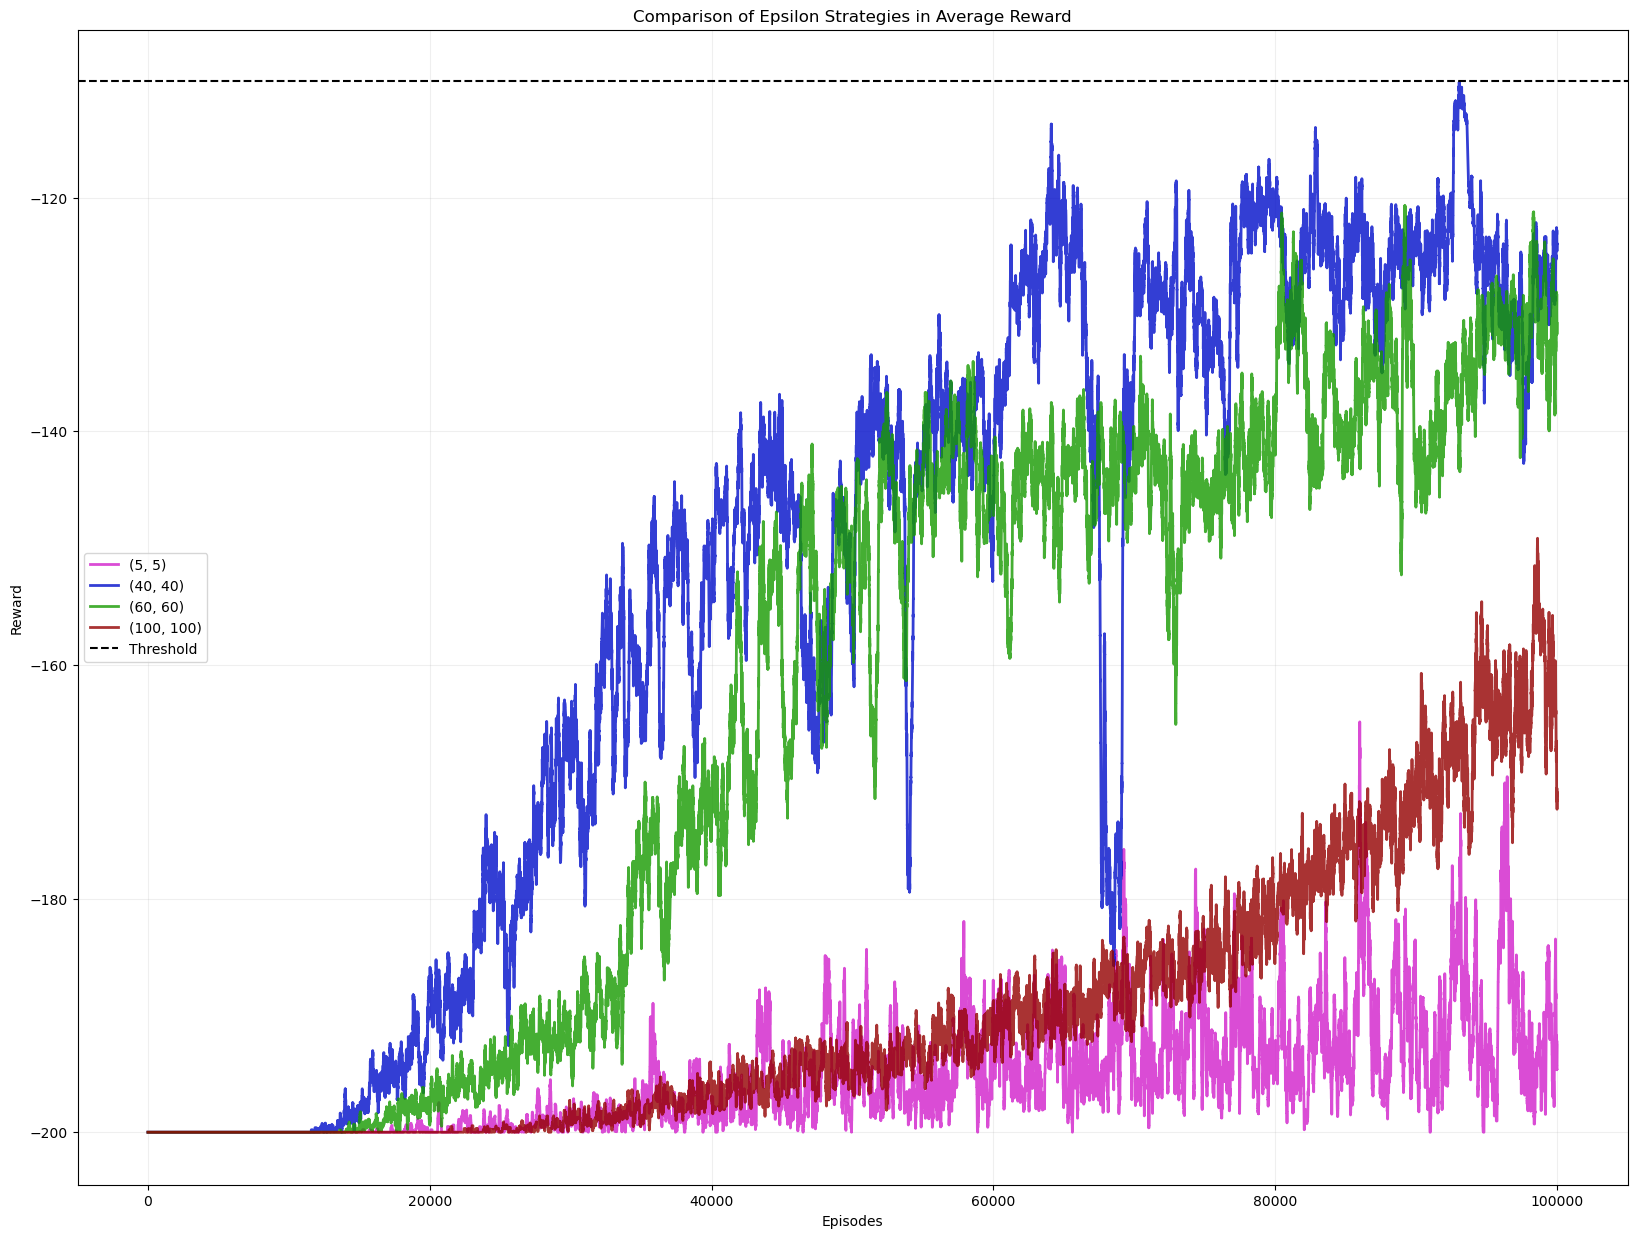

In [6]:
bucket_results = run_bucket_experiments(
    episodes=100000,
    seed=400
)

Analysis of this part is done in Questoin 2 in the end of the notebook.

### **PART 5: 3D VALUE FUNCTION VISUALIZATION**

In [14]:
def plot_value_function(agent : QLearningAgent):
    """
    Plot the learned state-value function V(s) = max_a Q(s, a) as a 3D surface.

    1. Compute V(s) = max_a Q(s, a) from the agent's Q-table.
    2. Mark unvisited states (where all Q-values are zero) as NaN so they are not plotted.
    3. Create position and velocity ranges based on the agent's discretization.
    4. Create a 3D surface plot over position, velocity, and V(s).
    """
    # Compute V(s) = max_a Q(s, a)
    state_values = np.max(agent.Q_table, axis=2)

    # Mark unvisited states
    unvisited = (agent.visit_count == 0)
    state_values[unvisited] = np.nan

    positions = np.linspace(agent.lower_bounds[0], agent.upper_bounds[0], agent.buckets[0])
    velocities = np.linspace(agent.lower_bounds[1], agent.upper_bounds[1], agent.buckets[1])

    position_mesh, velocity_mesh = np.meshgrid(positions, velocities, indexing="ij")

    figure = plt.figure(figsize=(20, 15))
    axis = figure.add_subplot(111, projection='3d')
    
    axis.plot_surface(position_mesh, velocity_mesh, state_values, cmap="plasma", edgecolor="none", alpha=0.8)

    axis.set_xlabel("Position")
    axis.set_ylabel("Velocity")
    axis.set_zlabel("State Values")
    axis.set_title("State Value Function")
    
    plt.show()

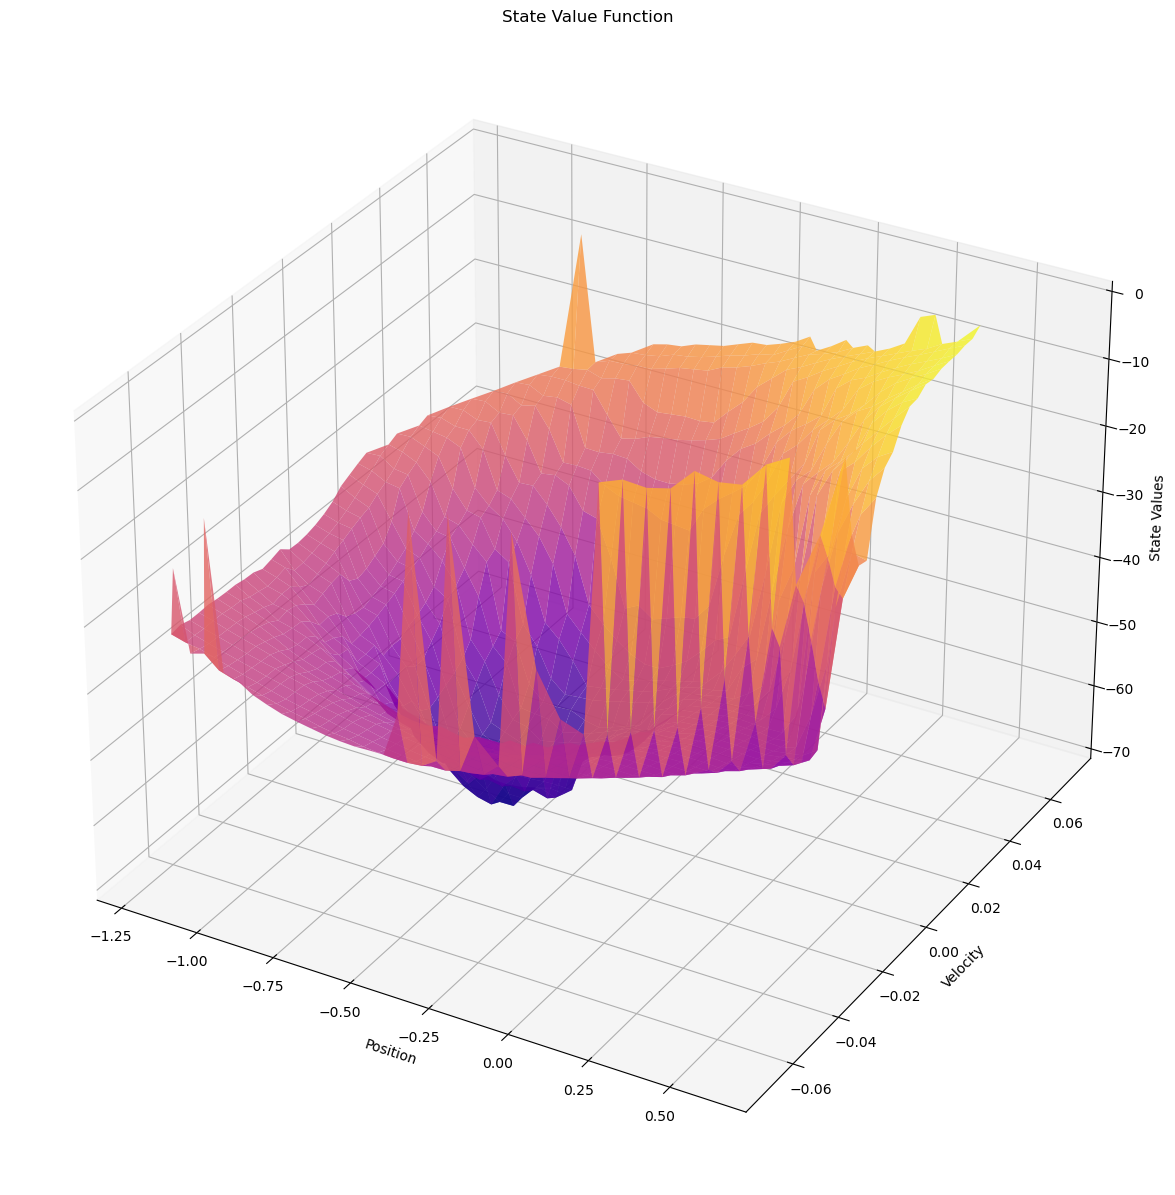

In [15]:
plot_value_function(visual_agent)

Analysis of the plot is in Question 9 at the end of the notebook

### ‌**PART 6: REWARD SHAPING (BONUS)**

In [ ]:
class ShapedCarAgent:
    def __init__(self, env, buckets=(40, 40), alpha=0.1, gamma=0.99, episodes=10000, mode='original', seed=400):
        self.env = env
        self.buckets = buckets
        self.alpha = alpha
        self.gamma = gamma
        self.episodes = episodes
        self.mode = mode
        self.seed = seed
        self.rng = np.random.default_rng(seed)
        
        self.lower_bounds = self.env.observation_space.low
        self.upper_bounds = self.env.observation_space.high
        self.Q_table = np.zeros(self.buckets + (self.env.action_space.n,))

    def discretize_state(self, obs):
        """
        Convert continuous observation to a discrete state index.

        1. Scale each component of obs to [0, 1] using lower_bounds and upper_bounds.
        2. Map the scaled value to a bucket index in [0, buckets[i] - 1].
        3. Clip the index to ensure it lies within valid range.
        4. Return the discrete state as a tuple of indices.
        """
        ratios = (obs - self.lower_bounds) / (self.upper_bounds - self.lower_bounds)        
        indices = np.floor(ratios * np.array(self.buckets)).astype(int)        
        indices = np.clip(indices, 0, np.array(self.buckets) - 1)       # Keep the values in [0, bucket_size - 1]
        
        return tuple(indices)           # Tuple so it's hashable

    def choose_action(self, state, epsilon):
        """
        Select an action using an epsilon-greedy policy.

        1. With probability epsilon, select a random action (exploration).
        2. Otherwise, select the greedy action (argmax over Q_table at this state).
        3. Return the selected action.
        """
        if self.rng.random() < epsilon:
            return int(self.rng.choice(self.env.action_space.n))
        return int(np.argmax(self.Q_table[state]))

    def get_epsilon(self, episode):
        """
        Compute epsilon for the given episode.
        TODO:
        1. Implement an epsilon schedule (e.g., logarithmic decay, linear decay, etc.).
        2. Make sure epsilon stays within [0.01, 1.0].
        """
        EPSILON_MAX = 1.0
        EPSILON_MIN = 0.01

        return max(EPSILON_MIN, 
                   np.exp(-5 * episode / self.episodes))
    
    def _shaped_reward(self, obs, next_obs, reward):
        position, velocity = obs
        next_poistion, next_velocity = next_obs

        if self.mode == "original":
            return reward
        
        if self.mode == "shaping1":
            phi_s = position
            phi_s_next = next_poistion
            shaping = self.gamma * phi_s_next - phi_s
            return reward + shaping
        
        if self.mode == "shaping2":
            phi_s = abs(velocity)
            phi_s_next = abs(next_velocity)
            shaping = self.gamma * phi_s_next - phi_s
            return reward + shaping
        
        if self.mode == "shaping3":
            phi_s = position + abs(velocity)
            phi_s_next = next_poistion + abs(next_velocity)
            shaping = self.gamma * phi_s_next - phi_s
            return reward + shaping 
        
        if self.mode == "hacked":
            return abs(next_velocity) * 10.0
        
        return reward

    def reset_env(self, episode=0):
        reset_result = self.env.reset(seed=self.seed + episode)

        if isinstance(reset_result, tuple):
            obs = reset_result[0]
        else:
            obs = reset_result

        return obs

    def train(self):
        """
        Train the shaped Q-learning agent.

        Returns:
            scores_array: list of original (environment) rewards per episode.
            success_array: list of 0/1 flags indicating whether the goal was reached.
        
        1. For each episode:
           - Reset the environment (optionally using a different seed per episode).
           - Discretize the initial observation.
           - Compute epsilon using get_epsilon.
        2. Run the episode loop:
           - Choose an action using epsilon-greedy.
           - Step the environment.
           - Discretize the next observation.
           - Compute a learning reward that depends on `mode`
           - Accumulate the original environment reward for logging.
        3. Log:
           - Append the total original reward to scores_array.
           - Append 1 to success_array if the goal was reached, else 0.
        """
        scores_array = []
        success_array = []
        
        for episode in range(self.episodes):
            # Reset environment
            obs = self.reset_env(episode)
            state = self.discretize_state(obs)

            # Compute epsilon
            epsilon = self.get_epsilon(episode)

            done =  False
            total_reward = 0.0
            reached_goal = False

            while not done:
                # Choose action using epsilon-greedy policy
                action = self.choose_action(state, epsilon)

                step_result = self.env.step(action)

                if len(step_result) == 4:
                    next_obs, reward, done, _ = step_result
                else:
                    next_obs, reward, terminated, truncated, _ = step_result
                    done = terminated or truncated

                # Check if goal is reached
                if next_obs[0] >= 0.5:
                    reached_goal = True

                next_state = self.discretize_state(next_obs)

                learning_reward = self._shaped_reward(obs, next_obs, reward)

                # Update Q-table 
                best_next_q = np.max(self.Q_table[next_state])
                td_target = learning_reward + self.gamma * best_next_q
                td_error = td_target - self.Q_table[state + (action,)]
                self.Q_table[state + (action,)] += self.alpha * td_error

                total_reward += reward
                obs = next_obs
                state = next_state

            scores_array.append(total_reward)
            success_array.append(1 if reached_goal else 0)

            # Log episode reward
            if (episode + 1) % 1000 == 0:
                print(f"Episode {episode + 1}/{self.episodes} | Average Reward: {np.mean(scores_array[-100:]):.2f} | Epsilon: {epsilon:.4f}")
        
        return scores_array, success_array


--- Training using original Mode ---
Episode 1000/10000 | Average Reward: -200.00 | Epsilon: 0.6068
Episode 2000/10000 | Average Reward: -200.00 | Epsilon: 0.3681
Episode 3000/10000 | Average Reward: -199.54 | Epsilon: 0.2232
Episode 4000/10000 | Average Reward: -194.79 | Epsilon: 0.1354
Episode 5000/10000 | Average Reward: -196.98 | Epsilon: 0.0821
Episode 6000/10000 | Average Reward: -180.58 | Epsilon: 0.0498
Episode 7000/10000 | Average Reward: -177.95 | Epsilon: 0.0302
Episode 8000/10000 | Average Reward: -174.85 | Epsilon: 0.0183
Episode 9000/10000 | Average Reward: -168.21 | Epsilon: 0.0111
Episode 10000/10000 | Average Reward: -169.27 | Epsilon: 0.0100

--- Training using hacked Mode ---
Episode 1000/10000 | Average Reward: -200.00 | Epsilon: 0.6068
Episode 2000/10000 | Average Reward: -200.00 | Epsilon: 0.3681
Episode 3000/10000 | Average Reward: -200.00 | Epsilon: 0.2232
Episode 4000/10000 | Average Reward: -200.00 | Epsilon: 0.1354
Episode 5000/10000 | Average Reward: -200.0

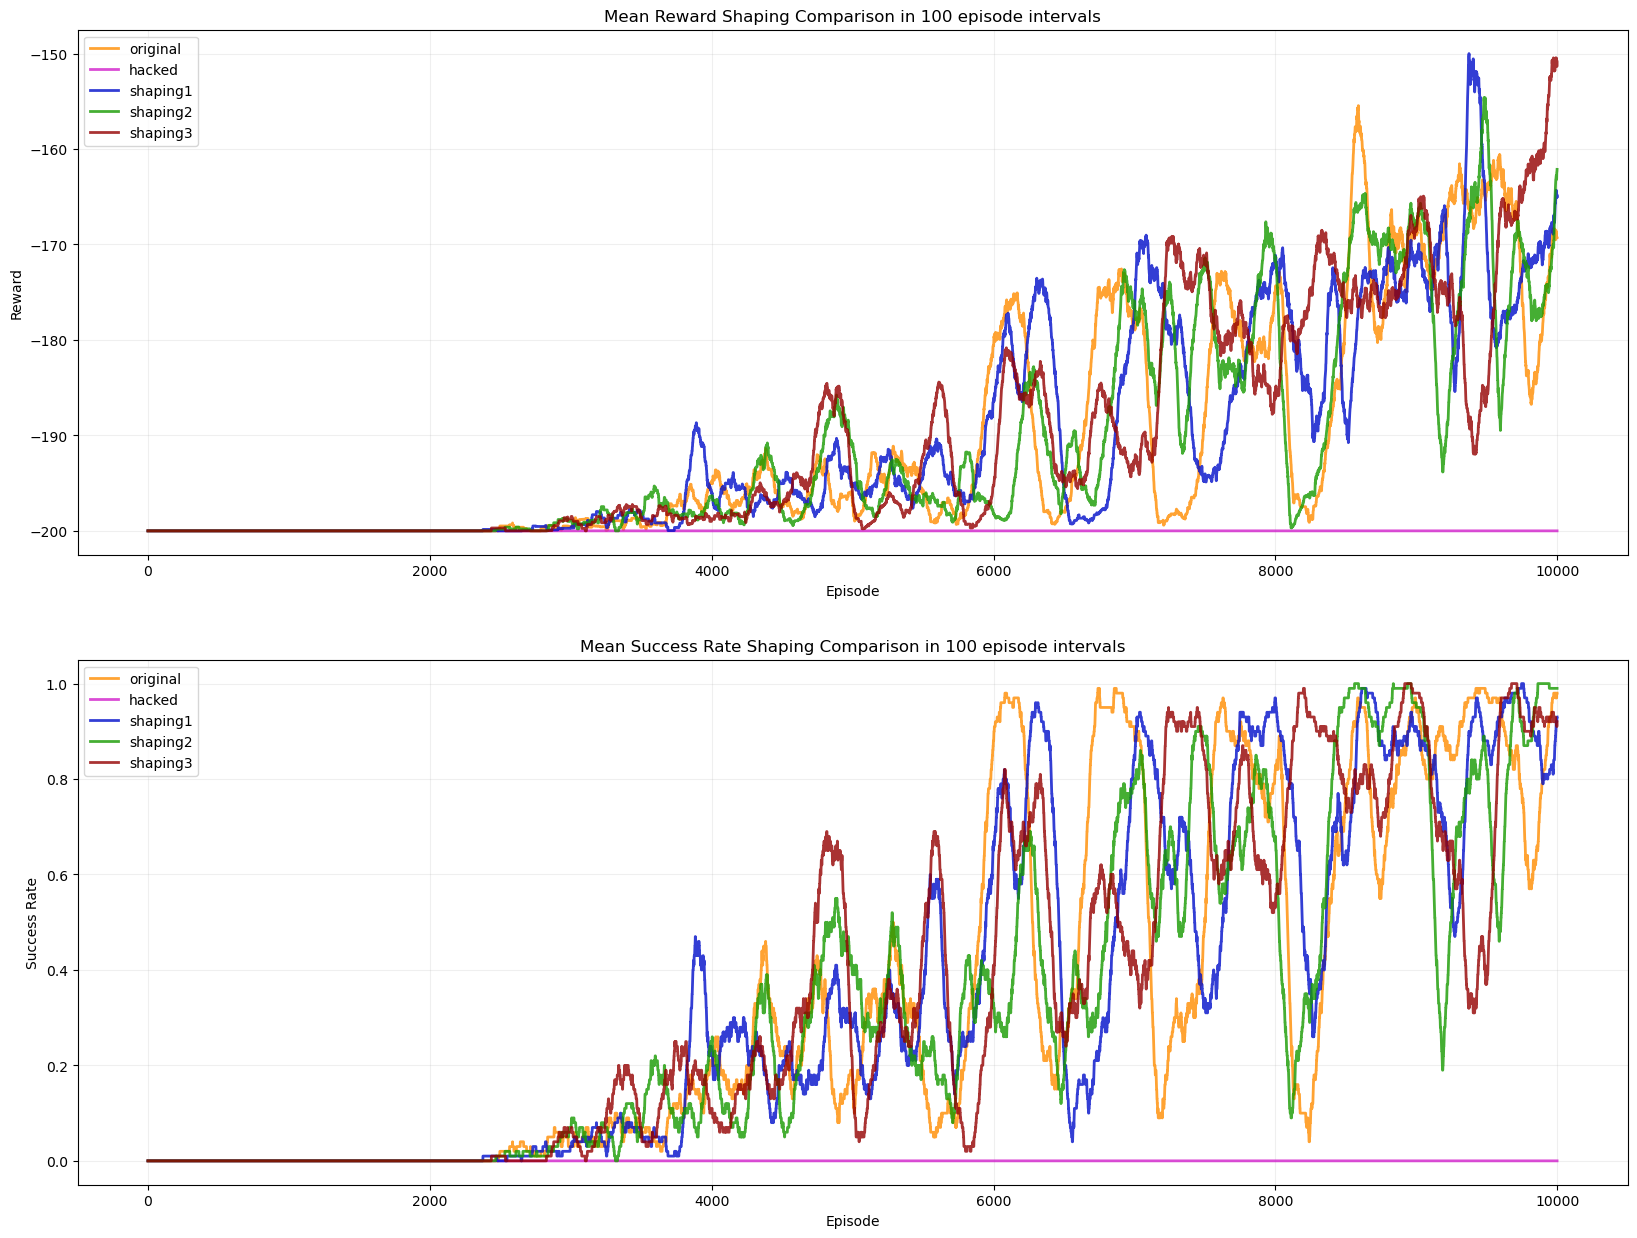

In [24]:
"""
Run reward shaping experiments and compare different modes:

1. Define the list of modes:
   ['original', 'hacked', 'shaping1', 'shaping2', 'shaping3']

2. For each mode:
   - Create a new MountainCar-v0 environment.
   - Initialize a ShapedCarAgent with the given mode.
   - Train the agent.
   - Store:
        * Episode rewards (original environment reward)
        * Success flags (0/1)
   - Close the environment.

3. Plot:
   - Smoothed learning curves (moving average of rewards).
   - Smoothed success rates (moving average of success flags).
"""

modes = ['original', 'hacked', 'shaping1', 'shaping2', 'shaping3']
results = {}

for mode in modes:
    print(f"\n--- Training using {mode} Mode ---")
    env = gym.make('MountainCar-v0')
    agent = ShapedCarAgent(
        env,
        mode=mode
    )
    scores, success = agent.train()
    env.close()

    results[mode] = {
        "scores": scores,
        "success": success
    }

def moving_average(arr, window=100):
    result = np.zeros(len(arr))
    for i in range(len(arr)):
        start = max(0, i - window + 1)
        result[i] = np.mean(arr[start:i + 1])

    return result

figure, axes = plt.subplots(2, 1, figsize=(20, 15))
colors = ["#FF8C00", "#D11FCB", "#000DCA", "#179A00", "#940000"]
for i, mode in enumerate(modes):
    axes[0].plot(moving_average(results[mode]["scores"]), color=colors[i], linewidth=2, alpha=0.8, label=mode)
    axes[1].plot(moving_average(results[mode]["success"]), color=colors[i], linewidth=2, alpha=0.8, label=mode)

axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Reward")
axes[0].set_title("Mean Reward Shaping Comparison in 100 episode intervals")
axes[0].legend()
axes[0].grid(True, alpha=0.2)

axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Success Rate")
axes[1].set_title("Mean Success Rate Shaping Comparison in 100 episode intervals")
axes[1].legend()
axes[1].grid(True, alpha=0.2)

plt.show()

- **<span style='color: #c60084'>original:</span>** Default Reward 
- **<span style='color: #c60084'>hacked:</span>** Reward = $10 \cdot |velocity|$ (hacks the metric without reaching the flag)

Shpaing uses a potential function for each state ($\phi(s)$) to add to the actual reward calculated by the environment itself. These will act like heuristics and make the agent move towards the goal faster. All of them return $reward + \gamma \cdot \phi(s') - \phi(s)$. The logic behind it is that potential decreases with $\gamma$ rate so the agents tries to get to the goal as soon as possible, and calculating a difference to see if the next state is better than current state.  
- **<span style='color: #c60084'>shaping1:</span>** $\phi(s) = position$
- **<span style='color: #c60084'>shaping2:</span>** $\phi(s) = |velocity|$
- **<span style='color: #c60084'>shaping3:</span>** $\phi(s) = position + |velocity|$

As wee see shaping helps the agent learn faster by pushing it towards getting good velocity and position which will lead to get to the goal easier and faster. On the other hand, hacking distracts the agents from the actual goal, focusing on the things that might be useful, but are not the actual goal.

---
## ❓ Questions 
---
### **<span style='color: #ce007b'>Q1: Reason of Discretize the state</span>**
Tabular Q-learning explicitly creates a mapping array (a lookup table) where every distinct state-action pair $(state, action)$ is allocated an individual entry cell. In continuous spaces, the state vectors consist of infinite real numbers (e.g., $position \in [-1.2, 0.6]$). Without discretization, the exact same continuous coordinates would almost never be visited twice. Consequently, the agent cannot match seen states to old table indexes, preventing value updates from backpropagating or converging into an actionable policy.

### **<span style='color: #ce007b'>Q2: Analyzing the impact of expanding or contracting the number of discrete states (buckets)</span>**
Too Few Buckets (e.g. $5 \times 5$): 
- Memory: Minimally low.
- Learning Speed: Very fast initial sweeps but fails to solve the environment
- Policy Quality: Extremely poor. The states are too broad to capture subtle physical adjustments like small speed increments, blinding the model to crucial changes.

Too Many Buckets (e.g. $100 \times 100$):
- Memory: Explodes quadratically (10000 discrete combinations $\times$ actions).
- Learning Speed: Extremely slow. The agent must visit thousands of individual tiny cells many times to propagate tabular value sequences.
- Policy Quality: Highly detailed if allowed to train for millions of runs, but practically impossible under standard timeline constraints due to sample inefficiency.

### **<span style='color: #ce007b'>Q3: How non-greedy actions are selected</span>**
In an $\epsilon$-greedy setup, the algorithm gives a minor probability of $\epsilon$ for exploration. When an exploration step occurs, non-greedy actions are selected uniformly at random from all possible valid moves.

### **<span style='color: #ce007b'>Q4: Another action selection policy:</span>**
Alternative Policy: Boltzmann (Softmax) Exploration. Instead of picking uniformly at random during exploration, actions are chosen probabilistically using a softmax distribution based on their estimated values:
$$P(a|s) = \frac{e^{Q(s,a)/t}}{\sum_{b \in A} e^{Q(s,b)/t}}$$
Here, $t$ represents a temperature variable. High temperatures cause actions to be chosen almost uniformly, while low temperatures keeps exploration heavily toward actions with better historical rewards. As the time passes, temperature decreases for the fact the agents has learned some things and should make the moves more logically (exploit) rather than random moves to just search the space (explore).

### **<span style='color: #ce007b'>Q5: Problems of bad α and γ:</span>**
- $\alpha$ Too Large ($\rightarrow$): The agent overwrites historical knowledge completely using the newest transition outcome, which prevents convergence.
- $\alpha$ Too Small ($\rightarrow 0$): Tabular updates become very small. The agent requires an enormous amount of episodes to learn, resulting in very high time consumption.
- $\gamma$ Too Large ($\rightarrow 1$): The agent weights later rewards with nearly equal value to immediate reward. In this way the agent doesn't understand that time is an important factor and should reach the goal as soon as possible.
- $\gamma$ Too Small ($\rightarrow 0$): The agent becomes highly shortsighted (it will only see the tip of its nose!). It prioritizes immediate local returns ($r = -1$) and ignores future better rewards, meaning it cannot plan to get higher rewards later.

### **<span style='color: #ce007b'>Q6: Problem of constant epsilon:</span>**
A fixed exploration rate means that even after training for hundreds of thousands of episodes and getting a perfect tabular map, the agent will still execute a completely random action 10% of the time. In highly sensitive environments like Mountain Car, executing a random action (such as braking near the goal) instantly destroys momentum, dragging the car back down the valley and the agent will be stuck there.

### **<span style='color: #ce007b'>Q7: Concept of State Aliasing:</span>**
State Aliasing occurs when distinct physical states map to the exact same discrete cell index in the agent's internal state table. In a $5 \times 5$ grid, a single cell represents a massive chunk of actual states. Within that single cell, the car could be moving fast to the left or slowing down to the right. Because the agent maps these opposite physical realities to the exact same lookup row, their opposing feedback loops cancel each other out during updates. The agent cannot distinguish its true context, preventing it from discovering a reliable policy.

### **<span style='color: #ce007b'>Q8: Learning speed on a 100 x 100 grid:</span>**
A $100 \times 100$ grid scales the state table up to 10000 discrete state chunks. Because Mountain Car provides a sparse reward, the agent only learns useful policies once it accidentally hits the goal and propagates those positive updates backward. The agent goes through unique, very small state spaces, rarely returning to the same cells (being like continous space). This makes it highly inefficient to backpropagate terminal goal rewards to the starting state.

### **<span style='color: #ce007b'>Q9: High value (V(s)) of negative velocities:</span>**
To be able to go to the right, the car's underpowered motor cannot fight gravity directly from a stuck position in the valley. It must first build up Potential Energy ($U = mgh$) by climbing up the opposite hill on the left. To climb the left hill, the car must move away from the goal, which by a negative velocity would be possible. The $Q$-learning agent successfully discovers this physical rule. It recognizes that states with a negative velocity at the bottom of the valley are essential to build the momentum needed to reach the goal. The value function assigns high values to these states because they directly lead to a high-velocity downward, converting potential energy back into the kinetic energy ($K = \frac{1}{2}mv^2$) required to get to the flag.

### **<span style='color: #ce007b'>Q10: Reward Hacking:</span>**
Reward Hacking occurs when an agent exploits loopholes in a poorly specified reward function to maximize its cumulative numerical score without actually achieving the actual goal.
- Common Variations:
    - Policy Looping: The agent discovers a repetitive sequence of safe sub-goals that yields consistent positive feedback without ever completing the actual goal.
    - Simulator Exploitation: The agent exploits physics engine errors, such as collision glitches, to gain massive velocity values that bypass typical real-world constraints.
- Consequences: This highlights that reinforcement learning agents optimize for the exact metric specified, not the implicit intent of the programmer. If a reward function is poorly designed with the ultimate goal, the agent will perfectly exploit the reward metric while completely failing to perform the intended task.